In [35]:
import os
import random
from datetime import datetime
from typing import List, Sequence, Tuple, Optional, Union, Callable, Literal, Dict, Any

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.metrics import (
    ConfusionMatrixDisplay,
    accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score,
)
from tqdm import tqdm

os.environ["PYTORCH_ENABLE_MPS_FALLBACK"] = "1"

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.autograd import Variable
from torch.utils import data
from torch.utils.data import ConcatDataset, DataLoader, Subset
from torch.utils.data import Dataset as TorchDataset

device = torch.device(
    "cuda"
    if torch.cuda.is_available()
    else "mps"
    if torch.backends.mps.is_available()
    else "cpu"
)


In [5]:
class Dataset(TorchDataset):
    """
    Sliding window dataset for Limit order book classification.

    Creates overlapping windows of sequential LOB snapshots for time-series
    classification tasks.
    
    Args:
        features (np.ndarray): Input features of shape (num_samples, num_features).
        labels (np.ndarray): Target labels of shape (num_samples,).
        num_features (int): Sliding window size (number of timestamps per sample).

    Raises:
        ValueError: If features and invalid or incompatible.
    """
    def __init__(self, features: np.ndarray, labels: np.ndarray, num_classes: int, seq_size: int):
        num_windows = features.shape[0] - seq_size + 1

        # Labels should match the number of windows. NOT row features
        if num_windows != labels.shape[0]:
            raise ValueError(
                f"Label count mismatch. Expected {num_windows} labels "
                f"(features={features.shape[0]} - seq_size={seq_size}), "
                f"got {labels.shape[0]}"
            )

        if seq_size < 1:
            raise ValueError("seq_size must be >= 1. Got {seq_size}")

        if features.shape[0] < seq_size:
            raise ValueError(
                "Not enough samples for seq_size={seq_size}. "
                f"Got {features.shape[0]} samples."
            )

        self.seq_size = seq_size
        self.num_features = features.shape[1]

        self._features = torch.from_numpy(features).float()
        self._labels= torch.from_numpy(labels).long()

    def __len__(self):
        return self._features.shape[0] - self.seq_size + 1

    def __getitem__(self, index: int) -> Tuple[torch.Tensor, torch.Tensor]:
        """ 
        Get a windows index.

        Args:
            index: Sample index.
        
        Returns:
            features: Tensor of shape (num_features, seq_size).
            label: Scaler label tensor for the last timestamp in the window.
        """
        # Extract window: (seq_size, num_features)
        window = self._features[index : index + self.seq_size, :]

        # Transpose to (num_features, seq_size) for Conv1d
        window = window.permute(1, 0)

        return window, self._labels[index]

In [6]:
def _load_block(path: str) -> np.ndarray:
    """
    Load dataset from text file. 
    
    Args:
        path: path to dataset text file.
    
    Returns:
        Loaded dataset as numpy array
    """
    return np.loadtxt(path)


def _make_Xy_from_block(
    data: np.ndarray, 
    horizon: int,
    seq_size: int,
    num_features: int,
) -> Tuple[np.ndarray, np.ndarray]:
    """
    Extract features (X) and labels (y) from a data block. 

    Args:
        data: Raw data array of shape (N, D) where N is rows and D is samples.
        horizon: Label horizon index. Maps to prediction windows:
            1 -> 100 ticks, 2 -> 50, 3 -> 30, 4 -> 20, 5 -> 10.
        seq_size: Sequence length for sliding window.
        num_features: Number of features rows to extract from data.

    Returns:
        X: Features array of shape (num_samples, num_features).
        y: Label array of shape (num_samples,) with values in [0, 1, 2].
    """
    # Extract labels from the horizon row, shift from (1, 2, 3). to (0, 1, 2)
    labels = data[-horizon, :].flatten()[seq_size - 1:] - 1
    
    # Extract features and transpose to (samples, features)
    features = data[:num_features, :].T

    return features, labels


def _build_concat_dataset(
    folds: Sequence[int],
    dir_path: str,
    prefix: str,
    horizon: int,
    seq_size: int,
    num_features: int,
) -> ConcatDataset:
    """
    Build a concatenated dataset from multiple fold files.
    
    Args:
        folds: List of fold indices to include.
        dir_path: Directory containing the fold files.
        prefix: Filename prefix for fold files.
        horizon: Label horizon index for prediction window.
        seq_size: Sequence length for sliding window.
        num_features: Number of features to extract.
    
    Returns:
        Concatenated dataset from all valid folds.
    
    Raises:
        ValueError: If no usable datasets are found.
    """
    datasets = []

    for fold_idx in folds:
        file_path = f"{dir_path}/{prefix}_{fold_idx}.txt"
        raw_data = _load_block(file_path)

        features, labels = _make_Xy_from_block(
            data=raw_data,
            horizon=horizon,
            seq_size=seq_size,
            num_features=num_features,
        )

        # skip folds with no valid samples
        if labels.shape[0] == 0:
            continue

        datasets.append(Dataset(features, labels, num_classes=3, seq_size=seq_size))

    if not datasets:
        raise ValueError("No usable datasets. All folds may be too short after alignment.")

    return ConcatDataset(datasets)


def _time_ordered_split(
    dataset: ConcatDataset,
    val_ratio: Optional[float],
) -> Tuple[ConcatDataset, Optional[Subset]]:
    """
    Splits dataset into train/validation sets preserving time order.

    Unlike random splitting, this maintains temporal ordering by using
    the first (1 - val_ratio) samples for training and the rest for validation.

    Args:
        dataset: Full dataset to split.
        val_ratio: Fraction of data to use for validation (0.0 to 1.0).
            If None or <= 0, no validation set is created.

    Returns:
        train_dataset: Training dataset.
        val_dataset: Validation dataset, or None if val_ratio is invalid.
    """
    if val_ratio is None or val_ratio <= 0:
        return dataset, None

    total_samples = len(dataset)
    train_size = int(total_samples * (1 - val_ratio))

    train_idx = list(range(train_size))
    val_idx = list(range(train_size, total_samples))

    return Subset(dataset, train_idx), Subset(dataset, val_idx)


def _extract_labels(dataset: ConcatDataset) -> np.ndarray:
    """
    Extract all labels from a dataset.

    Args:
        dataset: Dataset or Subset to extract labels from.

    Returns:
        Array of labels as int64.
    """
    labels = [int(dataset[i][1]) for i in range(len(dataset))]
    return np.asarray(labels, dtype=np.int64)


# Mapping from horizon to prediction window (in ticks)
HORIZON_TO_TICKS = {1: 100, 2: 50, 3: 30, 4: 20, 5: 10}


def make_loaders_for_fold(
    fold: int,
    horizon: int = 5,
    seq_size: int = 10,
    num_features: int = 144,
    batch_size: int = 128,
    train_dir: str = "../data/training",
    test_dir: str = "../data/testing",
    val_ratio: float = 0.0,
    num_folds: int = 9,
    test_horizon_folds: int = 1,
    test_folds: Optional[Sequence[int]] = None,
) -> tuple[DataLoader, DataLoader | None, DataLoader, np.ndarray]:
    """
    Create train, validation, and test data loaders for a given fold.

    Uses an expending window approach where training uses all folds up to
    and including the current fold, and testing uses subsequent folds.

    Args:
        fold: Current fold number (1-indexed)
        horizon: Label horizon index (1-5). See HORIZON_TO_TICKS for mapping.
        seq_size: Sequence length for sliding window.
        num_features: Number of LOB features to use.
        batch_size: batch size for data loaders.
        train_dir: Directory containing training fold files.
        test_dir: Directory containing test fold files.
        val_ratio: Fraction of training data to use for validation.
        num_folds: Total numbers of available folds.
        test_horizon_folds: Number of future folds to use for testing.
        test_folds: Explicit list of test fold indices. Overrides auto-selection.

    Returns:
        train_loader: DataLoader for training data.
        val_loader: DataLoader for validation data, or None if val_ratio <= 0.
        test_loader: DataLoader for test data.
        y_train: Array of training labels for class weight computation.
    
    Raises
        ValueError: If fold is out of range or train/test sets overlap.
    """
    # Validate fold number
    if not 1 <= fold <= num_folds:
        raise ValueError(f"fold must be in [1,{num_folds}], got {fold}.")

    # Define training fodls (expanding window)
    train_folds = list(range(1, fold + 1))

    # Define test folds (future folds)
    if test_folds is None:
        test_start = fold + 1
        test_end = min(fold + test_horizon_folds, num_folds)

        if test_start > num_folds:
            raise ValueError(
                "No future folds available for testing."
                f"Fold {fold} is the last available fold."
            )

        test_folds = list(range(test_start, test_end + 1))

    else:
        test_folds = list(test_folds)

    # Validate no overlap between train and test
    overlap = set(train_folds) & set(test_folds)
    if overlap:
        raise ValueError(f"Train/test overlap detected on folds: {overlap}")

    # Build datasets
    train_dataset_full = _build_concat_dataset(
        folds=train_folds,
        dir_path=train_dir,
        prefix="Train_Dst_NoAuction_ZScore_CF",
        horizon=horizon,
        seq_size=seq_size,
        num_features=num_features,
    )
    test_dataset = _build_concat_dataset(
        folds=test_folds,
        dir_path=test_dir,
        prefix="Test_Dst_NoAuction_ZScore_CF",
        horizon=horizon,
        seq_size=seq_size,
        num_features=num_features,
    )

    train_dataset, val_dataset = _time_ordered_split(train_dataset_full, val_ratio)

    # Create data loaders
    train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
    test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

    val_loader = None
    if val_dataset is not None:
        val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)  

    # Extract training labels for class weight computation
    y_train = _extract_labels(train_dataset)

    return train_loader, val_loader, test_loader, y_train

In [7]:
def set_seed(seed: int = 42):
    """
    Set the seed for all random number generators.

    Args:
        seed (int): The seed to set.
    """
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed(seed)
        torch.cuda.manual_seed_all(seed)

In [8]:
def compute_class_weights(
    labels: np.ndarray,
    num_classes: int = 3,
    scale: float = 1e6,
) -> torch.Tensor:
    """
    Compute inverse frequency class weights for imbalanced datasets.

    Assign higher weights to minority classes to balance their contribution
    during training. Uses formula: weight[c] = scale / count[c].
    
    Args:
        labels: Array of class labels with values in (0, num_classes).
        num_classes: Number of distinct classes.
        scale: Scaling factor for weight computation.

    Returns:
        Tensor of shape (num_classes,) with class weights on the target device.
    """
    class_counts = np.bincount(labels, minlength=num_classes)
    
    # Avoid division by zero for missing classes
    safe_counts = np.maximum(class_counts, 1)
    
    weights = scale / safe_counts

    return torch.tensor(weights, dtype=torch.float32, device=device)

In [31]:
def train_epoch(
    model: nn.Module,
    loader: DataLoader,
    optimizer: optim.Optimizer,
    criterion: nn.Module,
) -> tuple[float, float]:
    """
    Train the model for one epoch.

    Perform forward pass, backpropagation, and optimizer step for each batch.
    Accumulates loss and accuracy metrics across all batches.
    
    Args:
        model: Neural network model to train.
        loader: DataLoader providing (features, labels) batches.
        optimizer: Optimizer for updating model parameters.
        criterion: Loss function for computing training loss.
    
    Returns:
        avg_loss: Mean loss across all batches.
        avg_accuracy: Mean accuracy across all batches.
    """
    model.train()

    total_loss = 0.0
    total_correct = 0.0
    total_samples = 0

    for features, labels in loader:
        features = features.to(device, dtype=torch.float32)
        labels = labels.to(device, dtype=torch.long)

        # Forward pass
        optimizer.zero_grad()
        logits = model(features)
        loss = criterion(logits, labels)

        # Backward pass
        loss.backward()
        optimizer.step()

        # Accumulate metrics
        predictions = logits.argmax(dim=1)
        total_loss += loss.item() * labels.size(0)
        total_correct += (predictions == labels).sum().item()
        total_samples += labels.size(0)

    avg_loss = total_loss / total_samples
    avg_accuracy = total_correct / total_samples

    return avg_loss, avg_accuracy

In [10]:
@torch.no_grad()
def eval_epoch(
    model: nn.Module,
    loader: DataLoader,
    criterion: nn.Module,
    return_preds: bool = False,
) -> (
    tuple[float, float, float]
    | tuple[float, float, float, np.ndarray, np.ndarray]
):
    """
    Evaluate the model on a dataset.

    Compute loss, accuracy, and macro F1 score across all batches.
    Optionally return predictions for further analysis.

    Args:
        model: Neural network model to evaluate.
        loader: DataLoader providing (features, labels) batches.
        criterion: Loss function for computing evaluation loss.
        return_preds: If true, also return ground truth and predictions.

    Returns:
        avg_loss: Mean loss across all samples.
        accuracy: Classification accuracy (correct / total).
        macro_f1: Macro-averaged F1 score across all classes.
        y_true (optional): Ground truth labels if return_preds is True.
        y_pred (optional): Model predictions if return_preds is True.
    """
    model.eval()

    total_loss = 0.0
    total_samples = 0
    all_predictions: list[np.ndarray] = []
    all_labels: list[np.ndarray] = []

    for features, labels in loader:
        features = features.to(device, dtype=torch.float32)
        labels = labels.to(device, dtype=torch.long)

        # Forward pass
        logits = model(features)
        loss = criterion(logits, labels)

        # Accumulate metrics (sample-weighted)
        batch_size = labels.size(0)
        total_loss += loss.item() * batch_size
        total_samples += batch_size

        # Collect predictions 
        predictions = logits.argmax(dim=1)
        all_predictions.append(predictions.detach().cpu().numpy())
        all_labels.append(labels.detach().cpu().numpy())

    # Concatenate all batches
    y_pred = np.concatenate(all_predictions)
    y_true = np.concatenate(all_labels)

    # Compute metrics
    avg_loss = total_loss / max(total_samples, 1)
    accuracy = (y_pred == y_true).mean()
    macro_f1 = f1_score(y_true, y_pred, average="macro")

    if return_preds:
        return avg_loss, accuracy, macro_f1, y_true, y_pred

    return avg_loss, accuracy, macro_f1

In [11]:
class MLPBaseline(nn.Module):
    """
    Multi-Layer Perceptron baseline for LOB classification.

    A simple feed-forward network with flatten input and applies
    multiple fully-connected layers with dropout regularization.

    Args:
        num_classes: Number of ouput classes.
        num_features: Number of input features per timestep.
        seq_size: Number of timesteps in the input sequence.
        hidden_dims: Tuple of hidden layer dimensions.
        dropout: Dropout probability for regularization.

    Attributes:
        net: The feed-forward network.
    """
    def __init__(
        self,
        num_classes : int = 3,
        num_features : int = 144,
        seq_size : int = 10,
        hidden_dims : tuple[int] = (1024, 512, 256),
        dropout : float = 0.3,
    ):
        super().__init__()

        self.num_classes = num_classes
        self.num_features = num_features
        self.seq_size = seq_size
        
        input_dim = num_features * seq_size

        layers = [nn.Flatten()]
        prev_dim = input_dim

        for i, hidden_dim in enumerate(hidden_dims):
            layers.extend([
                nn.Linear(
                    in_features=prev_dim,
                    out_features=hidden_dim,
                ),
                nn.LeakyReLU(),
                nn.Dropout(p=dropout if i < len(hidden_dims) - 1 else 0.2),
            ])
            prev_dim = hidden_dim


        # Output layer
        layers.append(
            nn.Linear(
                in_features=prev_dim,
                out_features=num_classes,
            )
        )


        self.net = nn.Sequential(*layers)


    def forward(self, x : torch.Tensor) -> torch.Tensor:
        """
        Forward pass.

        Args:
            x: Input tensor of shape (batch, num_features, seq_size).


        Returns:
            Logits tensor of shape (batch, num_classes).
        """
        return self.net(x)


    def extra_repr(self) -> str:
        """ Return a string representation of the module configuration. """
        return f"num_classes={self.num_classes}, num_features={self.num_features}, seq_size={self.seq_size}"    

In [14]:
class CNNTimeBaseline(nn.Module):
    """
    1D CNN with temporal attention for time-series classification.

    Uses convolutional layers for feature extraction, attention machanism
    for temporal weighting, and fully-connected layers for classification.
    
    Args:
        num_classes (int): The number of classes in the classification task.
    
    Attributes:
        features (nn.Sequential): A sequence of convolutional layers.
        attention (nn.Sequential): A sequence of linear layers for attention mechanism.
        classifier (nn.Sequential): A sequence of linear layers for classification. 
    """

    def __init__(
        self,
        num_classes: int = 3,
        in_channels: int = 144,
        conv_channels: int = 128,
        attention_dim: int = 64,
        classifier_dim: int = 64,
        dropout: float = 0.2,
    ) -> None:
        super().__init__()

        self.num_classes = num_classes
        self.in_channels = in_channels
        self.conv_channels = conv_channels

        # Feature extractor: 1D convolutions over time
        self.features = nn.Sequential(
            nn.Conv1d(
                in_channels=in_channels,
                out_channels=conv_channels,
                kernel_size=3,
                padding=1
            ),
            nn.LeakyReLU(),
            nn.Conv1d(
                in_channels=conv_channels,
                out_channels=conv_channels,
                kernel_size=3,
                padding=1
            ),
            nn.LeakyReLU(),
            nn.Dropout(p=dropout),
        )

        # Attention: learns to weight timesteps by importance
        self.attention = nn.Sequential(
            nn.Linear(
                in_features=conv_channels, 
                out_features=attention_dim
            ),
            nn.Tanh(),
            nn.Linear(
                in_features=attention_dim,
                out_features=1
            ),
        )

        # Classifier head
        self.classifier = nn.Sequential(
            nn.Linear(
                in_features=conv_channels,
                out_features=classifier_dim
            ),
            nn.LeakyReLU(),
            nn.Dropout(p=dropout),
            nn.Linear(
                in_features=classifier_dim, 
                out_features=num_classes
            ),
        )

    def forward(
        self,
        x: torch.Tensor,
        return_attention: bool = False,
    ) -> Union[torch.Tensor, Tuple[torch.Tensor, torch.Tensor]]:
        """
        Forward pass with optional attention weights output.

        Args:
            x: Input tensor of shape (batch, in_channels, seq_len).
            return_attention: If true, also return attention weights.

        Returns:
            logits: Classification logits of shape (batch, num_classes)
            attn_weights (optional): Weights of shape (batch, seq_len, 1).
        """
        # Extract temporal features: (batch, conv_channels, seq_len)
        features = self.features(x)
        # Reshape for attention: (batch, seq_len, conv_channels)
        features = features.permute(0, 2, 1)

        # Compute attention weights: (batchm seq_len, 1)
        attention_weights = self.attention(features)
        attention_weights = torch.softmax(attention_weights, dim=1)

        # Weighted sum over time: (batch, conv_channels)
        context = (features * attention_weights).sum(dim=1)
        
        # Classification
        logits = self.classifier(context)

        if return_attention:
            return logits, attention_weights
        
        return logits


    def extra_repr(self) -> str:
        """ Return a string representation of model configuration. """
        return f"num_classes={self.num_classes}, in_channels={self.in_channels}, conv_channels={self.conv_channels}"

In [17]:
class TABLLayer(nn.Module):
    """
    Temporal Attention-augmented Bilinear Layer (TABL).
    
    Combines bilinear feature transformation with learnable temporal attention
    for time-series classification tasks.

    Args:
        in_dim: Number of input features.
        in_time: Number of input timesteps.
        out_dim: Number of output features.
        out_time: Number of output timesteps.
        activation: Activation function. Use None for no activation.
    
    Attributes:
        W1: Feature transform weights (out_dim, in_dim).
        W: Temporal attention weights (in_time, in_time).
        W2: Time projection weights (in_time, out_time).
        B: Bias (out_dim, out_time).
        lambda_param: Learned blend factor in [0, 1].
    """

    def __init__(
        self,
        in_dim : int,
        in_time : int,
        out_dim : int,
        out_time : int,
        activation : Optional[Callable[[torch.Tensor], torch.Tensor]] = F.leaky_relu,
    ) -> None:
        super().__init__()

        self.in_dim = in_dim
        self.in_time = in_time
        self.out_dim = out_dim
        self.out_time = out_time
        self.activation = activation

        # Learnable parameters
        self.W1 = nn.Parameter(torch.empty(out_dim, in_dim))
        self.W = nn.Parameter(torch.empty(in_time, in_time))
        self.W2 = nn.Parameter(torch.empty(in_time, out_time))
        self.B = nn.Parameter(torch.zeros(out_dim, out_time))
        self.lambda_param = nn.Parameter(torch.tensor(0.5))

        self._reset_parameters()

    def _reset_parameters(self) -> None:
        """ Initialize parameters with Xavier uniform and uniform attention. """
        nn.init.xavier_uniform_(self.W1)
        nn.init.xavier_uniform_(self.W2)
        nn.init.constant_(self.W, 1.0 / max(self.in_time, 1))

    def _compute_effective_attention(self) -> torch.Tensor:
        """
        Compute effective attention matrix with fixed diagonal.

        The diagonal is fixed to 1/T to prevent trivial self-attention.
        Off-diagonal elements are learned.
    
        Returns:
            Effective attention matrix of shape (in_time, in_time).
        """
        eye = torch.eye(
            self.in_time,
            device=self.W.device,
            dtype=self.W.dtype,
        )
        diagonal_value = 1.0 / max(self.in_time, 1)

        return self.W * (1.0 - eye) + diagonal_value * eye

    def forward(
        self,
        x: torch.Tensor,
        return_attention : bool = False,
    ) -> Union[torch.Tensor, tuple[torch.Tensor, torch.Tensor]]:
        """
        Forward pass of the TABL layer.

        Args:
            x: Input tensor of shape (batch, in_dim, in_time).
            return_attention: If True, also return attention weights.

        Returns:
            Output tensor of shape (batch, out_dim, out_time).
            If return_attention is True, also returns attention weights
            of shape (batch, out_dim, in_time).
        """
        # Feature transformation: (batch, in_dim, in_time) -> (batch, out_dim, in_time)
        x_bar = torch.matmul(self.W1, x)

        # Compute attention scores and weights
        W_eff = self._compute_effective_attention()
        attention_scores = torch.matmul(x_bar, W_eff)
        attention_weights = torch.softmax(attention_scores, dim=2)

        # Blend attended and original features using learned lambda
        lam = torch.clamp(self.lambda_param, min=0.0, max=1.0)
        x_attended = x_bar * attention_weights
        x_blended =  lam * x_attended + (1.0 - lam) * x_bar

        output = torch.matmul(x_blended, self.W2) + self.B
        
        if self.activation is not None:
            output = self.activation(output)

        if return_attention:
            return output, attention_weights

        return output

    def extra_repr(self) -> str:
        """ Return a string representation of the layer configuration. """
        return f"in_dim={self.in_dim}, in_time={self.in_time}, out_dim={self.out_dim}, out_time={self.out_time}, activation={self.activation.__name__}" 



class TABLClassifier(nn.Module):
    """
    TABL-based classifier for time-series classification.

    Uses a TABLLayer for temporal feature extraction followed by
    a fully-connected classification head.

    Args:
        num_classes: Number of output classes.
        in_dim: Number of input features per timestep.
        in_time: Number of input timesteps.
        hidden_dim: Hidden feature dimension in TABL layer.
        hidden_time: Hidden time dimension in TABL layer.
        classifier_dim: Hidden dimension in classification head.
        dropout: Dropout probability for regularization.
    """
    def __init__(
        self,
        num_classes : int,
        in_dim: int,
        in_time: int,
        hidden_dim: int,
        hidden_time: int,
        classifier_dim: int,
        dropout : float = 0.1,
    ):
        super().__init__()

        self.num_classes = num_classes
        self.in_dim = in_dim
        self.in_time = in_time
        self.hidden_dim = hidden_dim
        self.hidden_time = hidden_time

        # Temporal feature extractor
        self.tabl = TABLLayer(
            in_dim=in_dim,
            in_time=in_time,
            out_dim=hidden_dim,
            out_time=hidden_time,
            activation=F.leaky_relu,
        )

        # Classification head
        head_input_dim = hidden_dim * hidden_time
        self.head = nn.Sequential(
            nn.Flatten(),
            nn.Dropout(p=dropout),
            nn.Linear(
                in_features=head_input_dim,
                out_features=classifier_dim
            ),
            nn.ReLU(),
            nn.Dropout(p=dropout),
            nn.Linear(
                in_features=classifier_dim,
                out_features=num_classes
            ),
        )

    def forward(
        self,
        x: torch.Tensor,
        return_attention : bool = False,
    ) -> Union[torch.Tensor, tuple[torch.Tensor, torch.Tensor]]:
        """
        Forward pass of the classifier.

        Args:
            x: Input tensor of shape (batch, in_dim, in_time).
            return_attention: If True, also return attention weights from TABL.

        Returns:
            Logits tensor of shape (batch, num_classes).
            If return_attention is True, also returns attention weights
            of shape (batch, hidden_dim, in_time).
        """ 
        if return_attention:
            features, attention_weights = self.tabl(x, return_attention=True)
            logits = self.head(features)
            return logits, attention_weights

        features = self.tabl(x)
        logits = self.head(features)

        return logits


    def extra_repr(self) -> str:
        """ Return a string representation of the layer configuration. """
        return f"num_classes={self.num_classes}, in_dim={self.in_dim}, in_time={self.in_time}, hidden_dim={self.hidden_dim}, hidden_time={self.hidden_time}, classifier_dim={self.classifier_dim}, dropout={self.dropout}"

In [18]:
class BilinearNormalization(nn.Module):
    def __init__(self, D: int, T: int, eps: float = 1e-5):
        super().__init__()
        self.D = D
        self.T = T
        self.eps = eps

        self.gamma_t = nn.Parameter(torch.ones(D))
        self.beta_t = nn.Parameter(torch.zeros(D))

        self.gamma_f = nn.Parameter(torch.ones(T))
        self.beta_f = nn.Parameter(torch.zeros(T))

        self._w_t = nn.Parameter(torch.tensor(0.0))
        self._w_f = nn.Parameter(torch.tensor(0.0))

    @property
    def w_t(self):
        return F.softplus(self._w_t)

    @property
    def w_f(self):
        return F.softplus(self._w_f)

    def forward(self, x: torch.Tensor) -> torch.Tensor:

        B, D, T = x.shape
        assert D == self.D and T == self.T, (
            f"Expected (B,{self.D},{self.T}) got {x.shape}"
        )

        mu_t = x.mean(dim=2, keepdim=True)
        std_t = x.std(dim=2, keepdim=True, unbiased=False).clamp_min(self.eps)
        x_t = (x - mu_t) / std_t
        x_t = x_t * self.gamma_t.view(1, D, 1) + self.beta_t.view(1, D, 1)

        mu_f = x.mean(dim=1, keepdim=True)
        std_f = x.std(dim=1, keepdim=True, unbiased=False).clamp_min(self.eps)
        x_f = (x - mu_f) / std_f
        x_f = x_f * self.gamma_f.view(1, 1, T) + self.beta_f.view(1, 1, T)

        return self.w_t * x_t + self.w_f * x_f


class SinusoidalPositionalEncoding(nn.Module):
    def __init__(self, T: int, C: int):
        super().__init__()
        self.T = T
        self.C = C
        self.register_buffer("pe", torch.empty(0), persistent=False)

    def _build(self, device, dtype):
        T, C = self.T, self.C
        pe = torch.zeros(T, C, device=device, dtype=dtype)  # (T, C)
        position = torch.arange(0, T, device=device, dtype=dtype).unsqueeze(
            1
        )  # (T, 1)
        div_term = torch.exp(
            torch.arange(0, C, 2, device=device, dtype=dtype)
            * (-math.log(10000.0) / C)
        )
        pe[:, 0::2] = torch.sin(position * div_term)
        if C % 2 == 1:
            pe[:, 1::2] = torch.cos(position * div_term[:-1])
        else:
            pe[:, 1::2] = torch.cos(position * div_term)
        self.pe = pe.unsqueeze(0)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        if (
            self.pe.numel() == 0
            or self.pe.shape != (1, self.T, self.C)
            or self.pe.device != x.device
            or self.pe.dtype != x.dtype
        ):
            self._build(x.device, x.dtype)
        return x + self.pe


class MLPLOBMixer(nn.Module):
    def __init__(
        self,
        T: int,
        C: int,
        mlp_time: int = 64,
        mlp_feat: int = 256,
        dropout: float = 0.1,
    ):
        super().__init__()
        self.ln_time = nn.LayerNorm(T)
        self.fc_time1 = nn.Linear(T, mlp_time)
        self.fc_time2 = nn.Linear(mlp_time, T)

        self.ln_feat = nn.LayerNorm(C)
        self.fc_feat1 = nn.Linear(C, mlp_feat)
        self.fc_feat2 = nn.Linear(mlp_feat, C)

        self.drop = nn.Dropout(dropout)

    def forward(self, x: torch.Tensor) -> torch.Tensor:

        y = x.transpose(1, 2)
        y = self.ln_time(y)
        y = self.fc_time2(self.drop(F.gelu(self.fc_time1(y))))
        y = self.drop(y).transpose(1, 2)
        x = x + y

        y = self.ln_feat(x)
        y = self.fc_feat2(self.drop(F.gelu(self.fc_feat1(y))))
        y = self.drop(y)
        x = x + y
        return x


class DualAttentionBlock(nn.Module):
    def __init__(
        self,
        input_dim: int,
        time_steps: int,
        d_model: int = 144,
        n_heads_time: int = 4,
        d_feat_attn: int = 64,
        n_heads_feat: int = 4,
        dropout: float = 0.1,
    ):
        super().__init__()
        self.input_dim = input_dim
        self.time_steps = time_steps
        self.d_model = d_model
        self.d_feat_attn = d_feat_attn

        self.ln_time = nn.LayerNorm(d_model)
        self.attn_time = nn.MultiheadAttention(
            d_model, n_heads_time, dropout=dropout, batch_first=True
        )
        self.drop = nn.Dropout(dropout)

        self.proj_T_to_feat = nn.Linear(time_steps, d_feat_attn)
        self.proj_feat_to_T = nn.Linear(d_feat_attn, time_steps)

        self.ln_feat = nn.LayerNorm(d_feat_attn)
        self.attn_feat = nn.MultiheadAttention(
            d_feat_attn, n_heads_feat, dropout=dropout, batch_first=True
        )

        self.mixer = MLPLOBMixer(
            T=time_steps,
            C=d_model,
            mlp_time=max(16, time_steps * 4),
            mlp_feat=max(128, d_model * 2),
            dropout=dropout,
        )

    def forward(self, x: torch.Tensor, return_attn: bool = False):

        y = self.ln_time(x)
        y, attn_t = self.attn_time(
            y, y, y, need_weights=return_attn, average_attn_weights=False
        )
        x = x + self.drop(y)

        x_feat = x.transpose(1, 2)
        x_feat = self.proj_T_to_feat(x_feat)

        y = self.ln_feat(x_feat)
        y, attn_f = self.attn_feat(
            y, y, y, need_weights=return_attn, average_attn_weights=False
        )
        x_feat = x_feat + self.drop(y)

        x_feat = self.proj_feat_to_T(x_feat)
        x = x_feat.transpose(1, 2)
        x = self.mixer(x)

        if return_attn:
            return x, attn_t, attn_f
        return x


class TLOBClassifier(nn.Module):
    def __init__(
        self,
        num_classes: int = 3,
        input_dim: int = 144,
        time_steps: int = 10,
        d_model: int = 144,
        n_layers: int = 2,
        n_heads_time: int = 4,
        d_feat_attn: int = 64,
        n_heads_feat: int = 4,
        dropout: float = 0.1,
        use_bin: bool = True,
        use_pos_enc: bool = True,
        cls_pool: str = "last",
    ):
        super().__init__()
        self.input_dim = input_dim
        self.time_steps = time_steps
        self.d_model = d_model
        self.cls_pool = cls_pool

        self.bin = (
            BilinearNormalization(D=input_dim, T=time_steps)
            if use_bin
            else nn.Identity()
        )
        self.proj_in = (
            nn.Linear(input_dim, d_model)
            if d_model != input_dim
            else nn.Identity()
        )
        self.pos = (
            SinusoidalPositionalEncoding(T=time_steps, C=d_model)
            if use_pos_enc
            else nn.Identity()
        )

        self.blocks = nn.ModuleList([
            DualAttentionBlock(
                input_dim=input_dim,
                time_steps=time_steps,
                d_model=d_model,
                n_heads_time=n_heads_time,
                d_feat_attn=d_feat_attn,
                n_heads_feat=n_heads_feat,
                dropout=dropout,
            )
            for _ in range(n_layers)
        ])

        self.ln_out = nn.LayerNorm(d_model)
        self.head = nn.Sequential(
            nn.Dropout(dropout),
            nn.Linear(d_model, 128),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(128, num_classes),
        )

    def forward(self, x: torch.Tensor, return_attn: bool = False):
        x = self.bin(x)
        x = x.transpose(1, 2)
        x = self.proj_in(x)
        x = self.pos(x)

        attn_time_all = []
        attn_feat_all = []

        for blk in self.blocks:
            if return_attn:
                x, attn_t, attn_f = blk(x, return_attn=True)
                attn_time_all.append(attn_t)
                attn_feat_all.append(attn_f)
            else:
                x = blk(x)

        x = self.ln_out(x)

        h = x.mean(dim=1) if self.cls_pool == "mean" else x[:, -1, :]

        logits = self.head(h)

        if return_attn:
            return logits, attn_time_all, attn_feat_all
        return logits

In [32]:
def train_one_epoch(
    model: nn.Module,
    loader: DataLoader,
    optimizer: optim.Optimizer,
    criterion: nn.Module,
):
    """
    Train the model for one epoch.

    Performs forward pass, backpropagation, and the optimizer step for each batch.

    Args:
        model: Neural network model to train.
        loader: DataLoder providing (features, labels) batches.
        optimizer: Optimizer to use for training.
        criterion: Loss function to use for training.

    Returns:
        Avarage loss across all samples.
    """
    model.train()

    total_loss = 0.0
    total_samples = 0

    for features, labels in loader:
        features = features.to(device, dtype=torch.float32)
        labels = labels.to(device, dtype=torch.long)

        # Forward pass
        optimizer.zero_grad()
        logits = model(features)
        loss = criterion(logits, labels)

        # Backward pass
        loss.backward()
        optimizer.step()

        # Accumulate loss (sample-weighted)
        batch_size = labels.size(0)
        total_loss += loss.item() * batch_size
        total_samples += batch_size

    return total_loss / total_samples

In [23]:
@torch.no_grad()
def collect_avg_tabl_attention_per_class(
    model: nn.Module,
    loader: DataLoader,
    num_classes: int = 3,
    device: str = "cuda",
):
    """
    Collect average attention weights per class from a TABL model.

    Aggregates attention patterns across all samples, grouped by their
    true class label. Useful for visualizing what timesteps the mode
    focuses on for each class prediction.

    Args:
        model: TABL model wiht `return_attention=True`.
        loader: DataLoader providing (features, labels) batches.
        num_classes: Number of distinct classes.
        device: Device to run inference on. 
    """
    model.eval()

    seq_len = model.in_time
    attention_sum = np.zeros((num_classes, seq_len), dtype=np.float64)
    class_counts = np.zeros((num_classes,), dtype=np.int64)

    for features, labels in loader:
        features = features.to(device, dtype=torch.float32)
        labels = labels.to(device, dtype=torch.long)

        # Get attention weights from model
        _, attention = model(features, return_attention=True)
        
        # Average across feature dimension: (batch, hidden_dim, seq_len) -> (batch, seq_len)
        attention_per_time = attention.mean(dim=1)

        # Convert to numpy for aggregation
        attention_np = attention_per_time.detach().cpu().numpy()
        labels_np = labels.detach().cpu().numpy()

        # Accumulate attention per class
        for class_idx in range(num_classes):
            class_mask = labels_np == class_idx
            
            if class_mask.any():
                attention_sum[class_idx] += attention_np[class_mask].sum(axis=0)
                class_counts[class_idx] += class_mask.sum()

    # Compute average (avoid division by zero)
    avg_attention = attention_sum / np.maximum(class_counts[:, None], 1)
    return avg_attention, class_counts

In [25]:
@torch.no_grad()
def collect_avg_time_attention_per_class(
    model: nn.Module,
    loader: DataLoader,
    num_classes: int = 3,
    device: str = "cuda",
    layer: Literal["last", "mean"] = "last",
) -> Tuple[np.ndarray, np.ndarray]:
    """
    Collect average temporal attention weights per class.

    Aggregates attention across all samples, grouped by their
    true class label. Supports multi-layer attention models.

    Args:
        model: Model with `return_attn=True` support and `time_steps` attribute.
        loader: DataLoader providing (features, labels) batches.
        num_classes: Number of distinct classes.
        device: Device to run inference on.
        layer: Which layer's attention to use:
            - "last": Use only the final layer's attention.
            - "mean": Average attention across all layers.
    
    Returns:
        avg_attention: Array of shape (num_classes, time_steps) with mean
            attention weights per class.
        class_counts: Array of shape (num_classes,) with sample counts
            per class.
    """
    model.eval()

    time_steps = model.time_steps
    attention_sum = np.zeros((num_classes, time_steps), dtype=np.float64)
    class_counts = np.zeros((num_classes,), dtype=np.int64)

    for features, labels in loader:
        features = features.to(device, dtype=torch.float32)
        labels = labels.to(device, dtype=torch.long)

        # Get attention weights from model
        _, attention_layers, _ = model(features, return_attn=True)

        # Select layer(s) to use
        if layer == "last":
            attention = attention_layers[-1]
        else:
            # Average across all layers
            attention = torch.stack(attention_layers, dim=0).mean(dim=0)

        # Average across heads: (batch, heads, time, time) -> (batch, time, time)
        attention = attention.mean(dim=1)

        # Average across query positions: (batch, time, time) -> (batch, time) 
        attention = attention.mean(dim=1)

        # Convert to numpy for aggregation
        attention_np = attention.detach().cpu().numpy()
        labels_np = labels.detach().cpu().numpy()

        # Accumulate attention per class
        for class_idx in range(num_classes):
            class_mask = labels_np == class_idx

            if class_mask.any():
                attention_sum[class_idx] += attention_np[class_mask].sum(axis=0)
                class_counts[class_idx] += class_mask.sum()

    # Compute average (avoid division by zero)
    avg_attention = attention_sum / np.maximum(class_counts[:, None], 1)
    return avg_attention, class_counts

In [33]:
def plot_average_attention_history(
    attention_history: List[np.ndarray],
    title : str ="Average Attention over epochs",
    class_names: Optional[List[str]] = None,
    figsize: Tuple[float, float] = (15, 4.6),
) -> None:
    """
    Plot evolution of attention weights across training epochs.

    Visualizes how the model's attention over timesteps changes during
    training, separated by output class.

    Args:
        attention_history: List of attention arrays, oe per epoch.
            Each array has shape (num_classes, time_steps).
        title: Plot title.
        class_names: Names for each class. Defaults to ["Down", "Stationary", "Up"].
        figsize: Figure size as (width, height).
    """
    if class_names is None:
        class_names = ["Down", "Stationary", "Up"]
    
    # Stack history: (num_epochs, num_classes, time_steps)
    history = np.stack(attention_history, axis=0)
    num_epochs, num_classes, time_steps = history.shape

    # Create subplot for each class
    fig, axes = plt.subplots(1, num_classes, figsize=figsize, sharey=True)

    # Handle single class case
    if num_classes == 1:
        axes = [axes]

    for class_idx, ax in enumerate(axes):
        # Plot each timestep's attention evolution
        for t in range(time_steps):
            # Create label: t-9, t-8, ..., t-1, t
            offset = time_steps - 1 - t
            label = f"t-{offset}" if offset > 0 else "t"
            ax.plot(
                range(1, num_epochs + 1), 
                history[:, class_idx, t],
                label=label
            )

        ax.set_title(f"Movement: {class_names[class_idx]}")
        ax.set_xlabel("Epoch")
        ax.set_xlim(1, num_epochs)
        ax.grid(True, alpha=0.2)

    # Labels and legend
    axes[0].set_ylabel("Average Attention")
    axes[-1].legend(loc="best", ncol=2, fontsize=8)

    fig.suptitle(title, y=1.02, fontweight="bold")
    fig.tight_layout()
    plt.show()

In [36]:
def run_walk_forward_cv(
    model_builder: Callable[[], nn.Module],
    model_name: str,
    epochs: int =20,
    lr: float = 1e-3,
    batch_size: int = 128,
    horizon: int = 5,
    seq_size: int = 10,
    val_ratio: float = 0.0,
    num_folds: int = 8,
    track_attention: bool = False,
    attention_on: str = "test",
    attention_every: int = 1,
    attention_collector: Optional[Callable] = None,
    plot_attention: bool = False,
    plot_attention_title: Optional[str] = None,
) -> List[Dict[str, Any]]:
    """
    Run walk-forward cross-validation for time-series models.

    Uses an expanding window approach where each fold trains on all
    previous days and tests on the next day.

    Args:
        model_builder: Factory function that returns a fresh model instance.
        model_name: Name for logging and plot titles.
        epochs: Number of training epochs per fold.
        lr: Learning rate for Adam optimizer.
        batch_size: Batch size for data loaders.
        horizon: Prediction horizon index (1-5).
        seq_size: Sequence length for sliding window.
        val_ratio: Fraction of training data for validation (0 to disable).
        num_folds: Number of folds to evaluate.
        track_attention: Whether to collect attention weights during training.
        attention_on: Dataset to collect attention from ("train" or "test").
        attention_every: Collect attention every N epochs.
        attention_collector: Function to collect attention weights.
        plot_attention: Whether to plot attention evolution after each fold.
        plot_attention_title: Custom title for attention plots.

    Returns:
        List of fold results, each containing test metrics and predictions.    
    """
    set_seed(42)
    fold_results: List[Dict[str, Any]] = []

    print(f"\n{'=' * 50}")
    print(f"MODEL (Walk-Forward CV): {model_name}")
    print(f"{'=' * 50}\n")

    for fold in range(1, num_folds + 1):
        print(f"\n===== Fold {fold}: Train days 1..{fold} | Test day {fold + 1} =====")

        # Load data for this fold
        train_loader, val_loader, test_loader, y_train = make_loaders_for_fold(
            fold=fold,
            horizon=horizon,
            seq_size=seq_size,
            batch_size=batch_size,
            val_ratio=val_ratio,
        )

        # Compute class weights for imbalanced data
        weights = compute_class_weights(y_train.astype(np.long))
        weights = weights / weights.mean()
        criterion = nn.CrossEntropyLoss(weight=weights)

        # Initialize model and optimizer
        model = model_builder().to(device)
        optimizer = optim.Adam(model.parameters(), lr=lr)

        best_state: Optional[Dict[str, Any]] = None
        best_val_f1 = -1.0
        attention_history: List[np.ndarray] = []

        # Training loop
        for epoch in range(1, epochs + 1):
            train_loss, train_acc = train_epoch(model, train_loader, optimizer, criterion)

            # Validation
            if val_loader is not None:
                val_loss, val_acc, val_f1, _, _ = eval_epoch(model, val_loader, criterion, return_preds=True)
                print(f"Epoch {epoch:03d} | tr_loss {train_loss:.4f} acc {train_acc:.4f} | val_loss {val_loss:.4f} acc {val_acc:.4f} macroF1 {val_f1:.4f}")

                # Save best model based on validation F1
                if val_f1 > best_val_f1:
                    best_val_f1 = val_f1
                    best_state = {
                        key: value.detach().cpu().clone()
                        for key, value in model.state_dict().items()
                    }

            else:
                print(f"Epoch {epoch:03d} | tr_loss {tr_loss:.4f} acc {tr_acc:.4f}")

            # Collect attention weights
            if _should_collect_attention(track_attention, attention_collector, epoch, attention_every):
                attention_loader = test_loader if attention_on == "test" else train_loader
                try:
                    avg_attention, _ = attention_collector(model, attention_loader, num_classes=3, device=device)
                    attention_history.append(avg_attention)

                except Exception as e:
                    if epoch == 1 and fold == 1:
                        print(f"[warn] Attention tracking skipped: {e}")

        # Plot attention evolution
        if plot_attention and track_attention and len(attention_history) > 1:
            title = (plot_attention_title or f"{model_name} — Avg attention ({attention_on}) | fold {fold}")
            plot_average_attention_history(attention_history, title=title)

        # Restore best model
        if best_state is not None:
            model.load_state_dict(best_state)

        # Final evaluation on test set
        te_loss, te_acc, te_f1, y_true, y_pred = eval_epoch(model, test_loader, criterion, return_preds=True)
        print(f"Fold {fold} TEST | loss {te_loss:.4f} acc {te_acc:.4f} macroF1 {te_f1:.4f}")

        fold_results.append({
            "fold": fold,
            "test_loss": te_loss,
            "test_acc": te_acc,
            "test_f1": te_f1,
            "y_true": y_true,
            "y_pred": y_pred,
        })

    # Print summary
    _print_cv_summary(model_name, fold_results)
    return fold_results


def _should_collect_attention(
    track_attention: bool,
    attention_collector: Optional[Callable],
    epoch: int,
    attention_every: int,
) -> bool:
    """ Check if attention should be collected this epoch. """
    return (
        track_attention
        and attention_collector is not None
        and epoch % attention_every == 0
    )


def _print_cv_summary(model_name: str, fold_results: List[Dict[str, Any]]) -> None:
    """ Print cross-validation summary statistics. """
    accuracies = [r["test_acc"] for r in fold_results]
    f1_scores = [r["test_f1"] for r in fold_results]
    print(f"\n===== WALK-FORWARD SUMMARY: {model_name} =====")
    print(f"Test Accuracy  | mean={np.mean(accuracies):.4f} std={np.std(accuracies, ddof=0):.4f}")
    print(f"Test Macro F1  | mean={np.mean(f1_scores):.4f} std={np.std(f1_scores, ddof=0):.4f}")

In [37]:
class LSTMClassifier(nn.Module):
    """
    LSTM-based classifier for time-series classification.

    Uses a multi-layer LSTM for sequential feature extraction followed
    by a fully-connected classification head.

    Args:
        num_classes: Number of output classes.
        input_size: Number of input features per timesteps.
        hidden_size: LSTM hidden state dimension.
        num_layers: Number of stacked LSTM layers.
        classifier_dim: Hidden dimension in classifier head.
        dropout: Dropout probability for regularization.
    """
    def __init__(
        self,
        num_classes : int = 3,
        input_size : int = 144,
        hidden_size : int = 128,
        num_layers : int = 1,
        classifier_dim : int = 64,
        dropout : float = 0.2
    ) -> None:
        super().__init__()

        self.num_classes = num_classes
        self.input_size = input_size
        self.hidden_size = hidden_size
        self.num_classes = num_classes

        # LSTM requires dropout=0 for single layer 
        lstm_dropout = 0.0 if num_layers == 1 else dropout

        self.lstm = nn.LSTM(
            input_size=input_size,
            hidden_size=hidden_size,
            num_layers=num_layers,
            batch_first=True,
            dropout=lstm_dropout
        )

        self.head = nn.Sequential(
            nn.Linear(hidden_size, classifier_dim),
            nn.ReLU(),
            nn.Dropout(p=dropout),
            nn.Linear(classifier_dim, num_classes)
        )

    def forward(self, x):
        """
        Forward pass.

        Args:
            x: Input tensor of shape (batch, input_size, seq_len).
        
        Returns:
            Logits tensor of shape (batch, num_classes).
        """
        # LSTM expects (batch, seq_len, input_size)
        x = x.permute(0, 2, 1)
    
        # Run LSTM and extract final hidden state
        _, (hidden_state, _) = self.lstm(x)

        # Use hidden state from last layer: (num_layers, batch, hidden_size) -> (bathc, hidden_size)
        final_hidden = hidden_state[-1]

        # Classification
        logits = self.head(final_hidden) 

        return logits

In [38]:
class TCNBlock(nn.Module):
    """
    Temporal Convolutional Network (TCN) residual block.

    Applies dilates casual convolution with residual connections
    for efficient long-range temporal modeling.

    Args:
        in_channels: Number of input channels.
        out_channels: Number of output channels.
        kernel_size: Convolution kernel size.
        dilation: Dilation factor for receptive field expansion.
        dropout: Dropout probability for regularization.
    """
    def __init__(
        self,
        in_channels: int,
        out_channels: int,
        kernel_size: int = 3,
        dilation: int = 1,
        dropout: float = 0.2,
    ) -> None:
        super().__init__()

        self.in_channels = in_channels
        self.out_channels = out_channels
        self.dilation = dilation

        # Padding to maintain temporal dimension
        padding = (kernel_size - 1) * dilation // 2

        # Main convolutional path
        self.conv_block = nn.Sequential(
            nn.Conv1d(
                in_channels=in_channels, 
                out_channels=out_channels,
                kernel_size=kernel_size,
                padding=padding,
                dilation=dilation,
            ),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Conv1d(
                in_channels=out_channels,
                out_channels=out_channels,
                kernel_size=kernel_size,
                padding=padding,
                dilation=dilation,
            ),
            nn.ReLU(),
            nn.Dropout(dropout),
        )

        # Residual connection (1x1 conv if channels change, else identity)
        self.residual = (
            nn.Conv1d(
                in_channels=in_channels,
                out_channels=out_channels,
                kernel_size=1,
            )
            if in_channels != out_channels
            else nn.Identity()
        )

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        """
        Forward pass with residual connection.

        Args:
            x: Input tensor of shape (batch, in_channels, seq_len).

        Returns:
            Output tensor of shape (batch, out_channels, seq_len).
        """
        return self.conv_block(x) + self.residual(x)

    def extra_repr(self) -> str:
        """ Return a string representation of block configuration """
        return f"in_channels={self.in_channels}, out_channels={self.out_channels}, dilation={self.dilation}"


class TCNClassifier(nn.Module):
    """
    Temporal Convolutional Network classifier for time-series.
    
    Stacks multiple TCN blocks with increasing dilation for exponentially
    growing receptive field, followed by global pooling and classification.
    
    Args:
        num_classes: Number of output classes.
        in_channels: Number of input features per timestep.
        hidden_channels: Number of channels in TCN blocks.
        num_blocks: Number of TCN blocks to stack.
        kernel_size: Convolution kernel size.
        classifier_dim: Hidden dimension in classifier head.
        dropout: Dropout probability for regularization.
    """
    def __init__(
        self,
        num_classes: int = 3,
        in_channels: int = 144,
        hidden_channels: int = 128,
        num_blocks: int = 3,
        kernel_size: int = 3,
        classifier_dim: int = 64,
        dropout: float = 0.2,
    ) -> None:
        super().__init__()

        self.num_classes = num_classes
        self.in_channels = in_channels
        self.hidden_channels = hidden_channels

        # Build TCN blocks with exponentially growing dilation
        blocks: List[nn.Module] = []

        for i in range(num_blocks):
            block_in_channels = in_channels if i == 0 else hidden_channels
            dilation = 2 ** i # 1, 2, 4, 8, ...

            blocks.append(
                TCNBlock(
                    in_channels=block_in_channels,
                    out_channels=hidden_channels,
                    kernel_size=kernel_size,
                    dilation=dilation,
                    dropout=dropout,
                )
            )

        self.tcn = nn.Sequential(*blocks)

        # Classification head
        self.head = nn.Sequential(
            nn.Linear(hidden_channels, classifier_dim),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(classifier_dim, num_classes),
        )

    def forward(self, x):
        """
        Forward pass.
        Args:
            x: Input tensor of shape (batch, in_channels, seq_len).
        Returns:
            Logits tensor of shape (batch, num_classes).
        """
        # Extract temporal features
        features = self.tcn(x)
        # Global average pooling over time
        pooled = features.mean(dim=2)
        # Classification
        logits = self.head(pooled)
        return logits

    def extra_repr(self) -> str:
        """ Return a string representation of block configuration """
        return f"num_classes={self.num_classes}, in_channels={self.in_channels}, hidden_channels={self.hidden_channels}"

In [39]:
def summarize_cv(
    fold_results: List[Dict[str, Any]],
    model_name: str
) -> Tuple[pd.DataFrame, Dict[str, Any]]:
    """
    Summarize cross-validation results into a DataFrame and summary statistics.

    Computes mean and standard deviation of test metrics across all folds.

    Args:
        fold_results: List of fold result dictionaries, each containing
            'test_acc' and 'test_f1' keys.
        model_name: Name of the model for identification.

    Returns:
        results_df: DataFrame with per-fold results.
        summary: Dictionary with aggregated statistics.
    """

    results_df = pd.DataFrame(fold_results)
    summary = {
        "model": model_name,
        "acc_mean": results_df["test_acc"].mean(),
        "acc_std": results_df["test_acc"].std(ddof=0),
        "f1_mean": results_df["test_macroF1"].mean(),
        "f1_std": results_df["test_macroF1"].std(ddof=0),
    }
    return results_df, summary

In [159]:
mlp_results = run_walk_forward_cv(
    model_builder=lambda: MLPBaseline(
        num_classes=3,
        num_features=144,
        seq_size=10,
    ),
    model_name="MLP Baseline",
    epochs=20,
    lr=1e-3,
    batch_size=128,
    horizon=5,
    seq_size=10,
    val_ratio=0.1,
)


MODEL (Walk-Forward CV): MLP Baseline


===== Fold 1: Train days 1..1 | Test day 2 =====
Epoch 001 | tr_loss 1.0087 acc 0.5044 | val_loss 0.9766 acc 0.4753 macroF1 0.4576
Epoch 002 | tr_loss 0.9110 acc 0.5900 | val_loss 1.0271 acc 0.4090 macroF1 0.3981
Epoch 003 | tr_loss 0.8609 acc 0.6208 | val_loss 0.9244 acc 0.5700 macroF1 0.5354
Epoch 004 | tr_loss 0.8302 acc 0.6368 | val_loss 0.9333 acc 0.4419 macroF1 0.4465
Epoch 005 | tr_loss 0.7897 acc 0.6564 | val_loss 0.9491 acc 0.5032 macroF1 0.4933
Epoch 006 | tr_loss 0.7600 acc 0.6629 | val_loss 0.9278 acc 0.5718 macroF1 0.5397
Epoch 007 | tr_loss 0.7312 acc 0.6810 | val_loss 0.9232 acc 0.6074 macroF1 0.5627
Epoch 008 | tr_loss 0.7029 acc 0.6914 | val_loss 0.9819 acc 0.5900 macroF1 0.5422
Epoch 009 | tr_loss 0.6783 acc 0.6979 | val_loss 0.9548 acc 0.4978 macroF1 0.4793
Epoch 010 | tr_loss 0.6528 acc 0.7111 | val_loss 0.9527 acc 0.6446 macroF1 0.5695
Epoch 011 | tr_loss 0.6239 acc 0.7195 | val_loss 1.0079 acc 0.4510 macroF1 0.4461
Epoch 01

In [160]:
cnn_results = run_walk_forward_cv(
    model_builder=lambda: CNNTimeBaseline(num_classes=3),
    model_name="CNN Time Baseline",
    epochs=20,
    lr=1e-3,
    val_ratio=0.1 
)


MODEL (Walk-Forward CV): CNN Time Baseline


===== Fold 1: Train days 1..1 | Test day 2 =====
Epoch 001 | tr_loss 0.9759 acc 0.5452 | val_loss 0.9376 acc 0.5738 macroF1 0.5319
Epoch 002 | tr_loss 0.8376 acc 0.6398 | val_loss 0.8887 acc 0.4925 macroF1 0.4955
Epoch 003 | tr_loss 0.7685 acc 0.6834 | val_loss 0.8667 acc 0.5900 macroF1 0.5634
Epoch 004 | tr_loss 0.7217 acc 0.7079 | val_loss 0.8841 acc 0.7036 macroF1 0.6306
Epoch 005 | tr_loss 0.6850 acc 0.7225 | val_loss 0.8220 acc 0.6649 macroF1 0.6261
Epoch 006 | tr_loss 0.6372 acc 0.7448 | val_loss 0.7934 acc 0.6606 macroF1 0.6244
Epoch 007 | tr_loss 0.6054 acc 0.7613 | val_loss 0.8097 acc 0.7105 macroF1 0.6566
Epoch 008 | tr_loss 0.5648 acc 0.7744 | val_loss 0.7730 acc 0.6793 macroF1 0.6427
Epoch 009 | tr_loss 0.5446 acc 0.7819 | val_loss 0.8732 acc 0.7393 macroF1 0.6874
Epoch 010 | tr_loss 0.5147 acc 0.7963 | val_loss 0.7858 acc 0.7208 macroF1 0.6732
Epoch 011 | tr_loss 0.4994 acc 0.7978 | val_loss 0.8245 acc 0.7226 macroF1 0.6759
Epo

In [161]:
lstm_results = run_walk_forward_cv(
    model_builder=lambda: LSTMClassifier(num_classes=3, hidden_size=128),
    model_name="LSTM",
    epochs=20,
    lr=1e-3,
    val_ratio=0.1
)


MODEL (Walk-Forward CV): LSTM


===== Fold 1: Train days 1..1 | Test day 2 =====
Epoch 001 | tr_loss 0.9635 acc 0.5539 | val_loss 0.9374 acc 0.5082 macroF1 0.4947
Epoch 002 | tr_loss 0.7964 acc 0.6592 | val_loss 0.8811 acc 0.5723 macroF1 0.5486
Epoch 003 | tr_loss 0.7101 acc 0.7035 | val_loss 0.8592 acc 0.6072 macroF1 0.5737
Epoch 004 | tr_loss 0.6410 acc 0.7294 | val_loss 0.8676 acc 0.5829 macroF1 0.5587
Epoch 005 | tr_loss 0.5780 acc 0.7547 | val_loss 0.8728 acc 0.6431 macroF1 0.6033
Epoch 006 | tr_loss 0.5184 acc 0.7780 | val_loss 0.9128 acc 0.6090 macroF1 0.5776
Epoch 007 | tr_loss 0.4623 acc 0.7998 | val_loss 0.9734 acc 0.6484 macroF1 0.5999
Epoch 008 | tr_loss 0.4093 acc 0.8206 | val_loss 0.9724 acc 0.5594 macroF1 0.5429
Epoch 009 | tr_loss 0.3599 acc 0.8421 | val_loss 1.0787 acc 0.6082 macroF1 0.5689
Epoch 010 | tr_loss 0.3148 acc 0.8564 | val_loss 1.1745 acc 0.6398 macroF1 0.5860
Epoch 011 | tr_loss 0.2697 acc 0.8738 | val_loss 1.2795 acc 0.6315 macroF1 0.5790
Epoch 012 | tr_l

In [162]:
tcn_results = run_walk_forward_cv(
    model_builder=lambda: TCNClassifier(num_classes=3),
    model_name="TCN",
    epochs=20,
    lr=1e-3,
    val_ratio=0.1
)



MODEL (Walk-Forward CV): TCN


===== Fold 1: Train days 1..1 | Test day 2 =====
Epoch 001 | tr_loss 1.0037 acc 0.5111 | val_loss 0.9444 acc 0.5386 macroF1 0.5133
Epoch 002 | tr_loss 0.8842 acc 0.6177 | val_loss 0.8981 acc 0.5426 macroF1 0.5225
Epoch 003 | tr_loss 0.8153 acc 0.6506 | val_loss 0.8544 acc 0.6138 macroF1 0.5782
Epoch 004 | tr_loss 0.7768 acc 0.6667 | val_loss 0.8824 acc 0.5604 macroF1 0.5341
Epoch 005 | tr_loss 0.7407 acc 0.6840 | val_loss 0.8492 acc 0.6274 macroF1 0.5906
Epoch 006 | tr_loss 0.7108 acc 0.6954 | val_loss 0.8912 acc 0.6515 macroF1 0.5947
Epoch 007 | tr_loss 0.6894 acc 0.7074 | val_loss 0.8897 acc 0.6209 macroF1 0.5745
Epoch 008 | tr_loss 0.6594 acc 0.7157 | val_loss 0.8503 acc 0.6171 macroF1 0.5874
Epoch 009 | tr_loss 0.6372 acc 0.7264 | val_loss 0.8451 acc 0.5733 macroF1 0.5559
Epoch 010 | tr_loss 0.6178 acc 0.7333 | val_loss 0.8670 acc 0.5854 macroF1 0.5665
Epoch 011 | tr_loss 0.5975 acc 0.7393 | val_loss 0.8952 acc 0.5867 macroF1 0.5661
Epoch 012 | tr_lo

In [ ]:
tabl_results = run_walk_forward_cv(
    model_builder=lambda: TABLClassifier(
        num_classes=3,
        in_dim=144,
        in_time=10,
        hidden_dim=64,
        hidden_time=5,
        classifier_dim=64,
    ),
    model_name="TABL",
    val_ratio=0.1,
    track_attention=True,
    attention_every=1,
    attention_on="test",
    attention_collector=collect_avg_tabl_attention_per_class,
    plot_attention=True,
    plot_attention_title="TABL — Avg attention (test)",
)


MODEL (Walk-Forward CV): TABL


===== Fold 1: Train days 1..1 | Test day 2 =====



MODEL (Setup1 walk-forward): TLOB (dual-attn + BiN + sinusoidal PE)


===== Fold 1: Train days 1..1 | Test day 2 =====
Epoch 001 | tr_loss 0.6311 acc 0.7320 | val_loss 0.5978 acc 0.7758 macroF1 0.7474
Epoch 002 | tr_loss 0.4620 acc 0.8143 | val_loss 0.5516 acc 0.8052 macroF1 0.7766
Epoch 003 | tr_loss 0.4126 acc 0.8244 | val_loss 0.5138 acc 0.7948 macroF1 0.7709
Epoch 004 | tr_loss 0.3833 acc 0.8314 | val_loss 0.5611 acc 0.7963 macroF1 0.7690
Epoch 005 | tr_loss 0.3556 acc 0.8367 | val_loss 0.5589 acc 0.8045 macroF1 0.7771
Epoch 006 | tr_loss 0.3277 acc 0.8423 | val_loss 0.5003 acc 0.7733 macroF1 0.7537
Epoch 007 | tr_loss 0.3005 acc 0.8508 | val_loss 0.5418 acc 0.7880 macroF1 0.7631
Epoch 008 | tr_loss 0.2847 acc 0.8564 | val_loss 0.6306 acc 0.7908 macroF1 0.7633
Epoch 009 | tr_loss 0.2624 acc 0.8649 | val_loss 0.6320 acc 0.7910 macroF1 0.7602
Epoch 010 | tr_loss 0.2397 acc 0.8723 | val_loss 0.6779 acc 0.7999 macroF1 0.7721
Epoch 011 | tr_loss 0.2280 acc 0.8781 | val_loss 0.6938 acc 

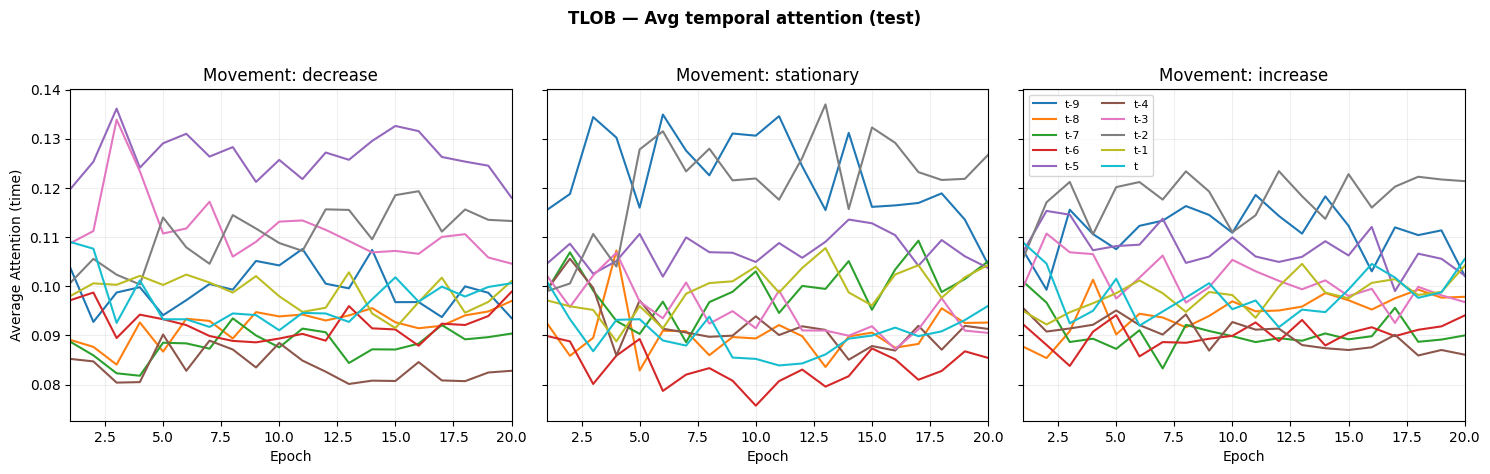

Fold 1 TEST | loss 0.4934 acc 0.8185 macroF1 0.7926

===== Fold 2: Train days 1..2 | Test day 3 =====
Epoch 001 | tr_loss 0.5913 acc 0.7519 | val_loss 0.4771 acc 0.8251 macroF1 0.7857
Epoch 002 | tr_loss 0.4539 acc 0.8133 | val_loss 0.4487 acc 0.7896 macroF1 0.7599
Epoch 003 | tr_loss 0.4186 acc 0.8174 | val_loss 0.4013 acc 0.8070 macroF1 0.7785
Epoch 004 | tr_loss 0.3958 acc 0.8216 | val_loss 0.3978 acc 0.8116 macroF1 0.7828
Epoch 005 | tr_loss 0.3750 acc 0.8245 | val_loss 0.3893 acc 0.8165 macroF1 0.7890
Epoch 006 | tr_loss 0.3580 acc 0.8277 | val_loss 0.3987 acc 0.8144 macroF1 0.7870
Epoch 007 | tr_loss 0.3398 acc 0.8322 | val_loss 0.4116 acc 0.8106 macroF1 0.7811
Epoch 008 | tr_loss 0.3215 acc 0.8386 | val_loss 0.4461 acc 0.8112 macroF1 0.7786
Epoch 009 | tr_loss 0.3063 acc 0.8430 | val_loss 0.4524 acc 0.8168 macroF1 0.7867
Epoch 010 | tr_loss 0.2892 acc 0.8480 | val_loss 0.4640 acc 0.8102 macroF1 0.7795
Epoch 011 | tr_loss 0.2738 acc 0.8530 | val_loss 0.5094 acc 0.8232 macroF1 0.7

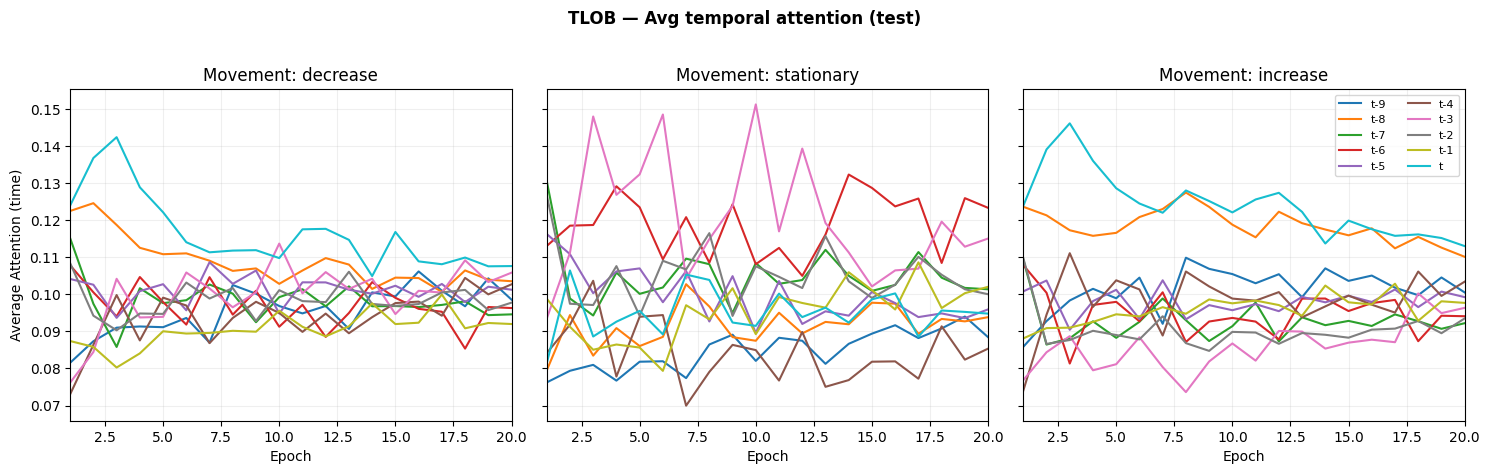

Fold 2 TEST | loss 0.6340 acc 0.8367 macroF1 0.7983

===== Fold 3: Train days 1..3 | Test day 4 =====
Epoch 001 | tr_loss 0.5416 acc 0.7742 | val_loss 0.4294 acc 0.8353 macroF1 0.7879
Epoch 002 | tr_loss 0.4332 acc 0.8132 | val_loss 0.3765 acc 0.8367 macroF1 0.7936
Epoch 003 | tr_loss 0.4055 acc 0.8172 | val_loss 0.3673 acc 0.8381 macroF1 0.7962
Epoch 004 | tr_loss 0.3873 acc 0.8201 | val_loss 0.3738 acc 0.8387 macroF1 0.7965
Epoch 005 | tr_loss 0.3732 acc 0.8229 | val_loss 0.3700 acc 0.8308 macroF1 0.7905
Epoch 006 | tr_loss 0.3590 acc 0.8242 | val_loss 0.3768 acc 0.8357 macroF1 0.7937
Epoch 007 | tr_loss 0.3456 acc 0.8278 | val_loss 0.3831 acc 0.8351 macroF1 0.7926
Epoch 008 | tr_loss 0.3319 acc 0.8326 | val_loss 0.3936 acc 0.8393 macroF1 0.7961
Epoch 009 | tr_loss 0.3177 acc 0.8367 | val_loss 0.4061 acc 0.8341 macroF1 0.7911
Epoch 010 | tr_loss 0.3060 acc 0.8389 | val_loss 0.4136 acc 0.8421 macroF1 0.7991
Epoch 011 | tr_loss 0.2924 acc 0.8430 | val_loss 0.4205 acc 0.8386 macroF1 0.7

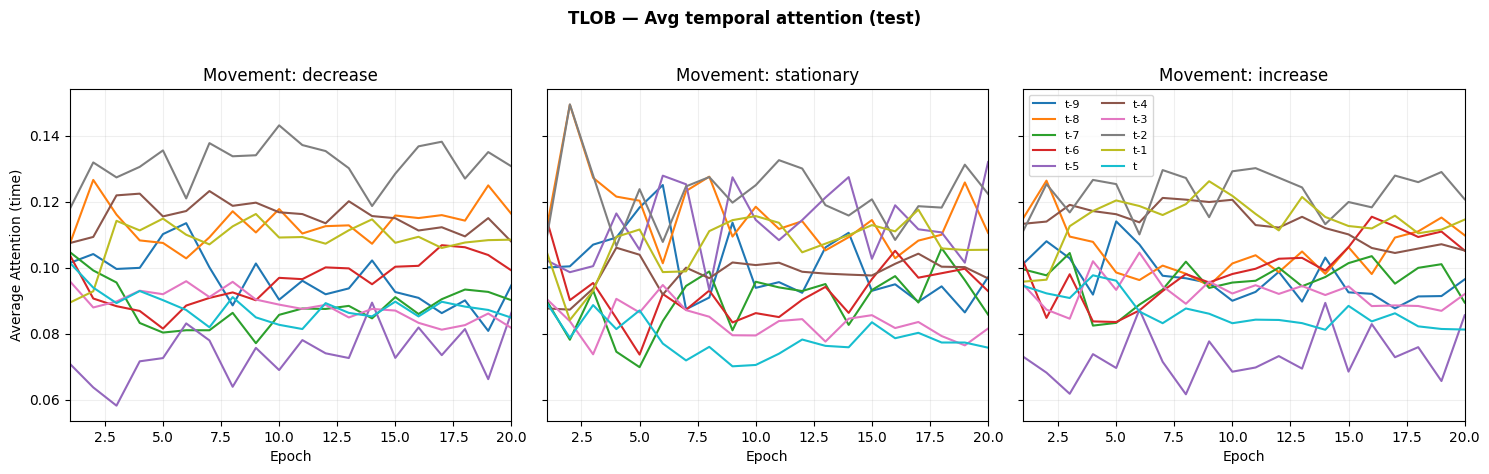

Fold 3 TEST | loss 0.4204 acc 0.8116 macroF1 0.7909

===== Fold 4: Train days 1..4 | Test day 5 =====
Epoch 001 | tr_loss 0.5150 acc 0.7842 | val_loss 0.4418 acc 0.8172 macroF1 0.7808
Epoch 002 | tr_loss 0.4142 acc 0.8164 | val_loss 0.3977 acc 0.8379 macroF1 0.8017
Epoch 003 | tr_loss 0.3940 acc 0.8208 | val_loss 0.3709 acc 0.8171 macroF1 0.7871
Epoch 004 | tr_loss 0.3774 acc 0.8221 | val_loss 0.3766 acc 0.8284 macroF1 0.7981
Epoch 005 | tr_loss 0.3681 acc 0.8231 | val_loss 0.3664 acc 0.8251 macroF1 0.7934
Epoch 006 | tr_loss 0.3547 acc 0.8258 | val_loss 0.3975 acc 0.8280 macroF1 0.7961
Epoch 007 | tr_loss 0.3444 acc 0.8279 | val_loss 0.3943 acc 0.8226 macroF1 0.7911
Epoch 008 | tr_loss 0.3325 acc 0.8302 | val_loss 0.4264 acc 0.8206 macroF1 0.7886
Epoch 009 | tr_loss 0.3205 acc 0.8341 | val_loss 0.4788 acc 0.8228 macroF1 0.7893
Epoch 010 | tr_loss 0.3099 acc 0.8374 | val_loss 0.4431 acc 0.8239 macroF1 0.7885
Epoch 011 | tr_loss 0.2983 acc 0.8424 | val_loss 0.5015 acc 0.8268 macroF1 0.7

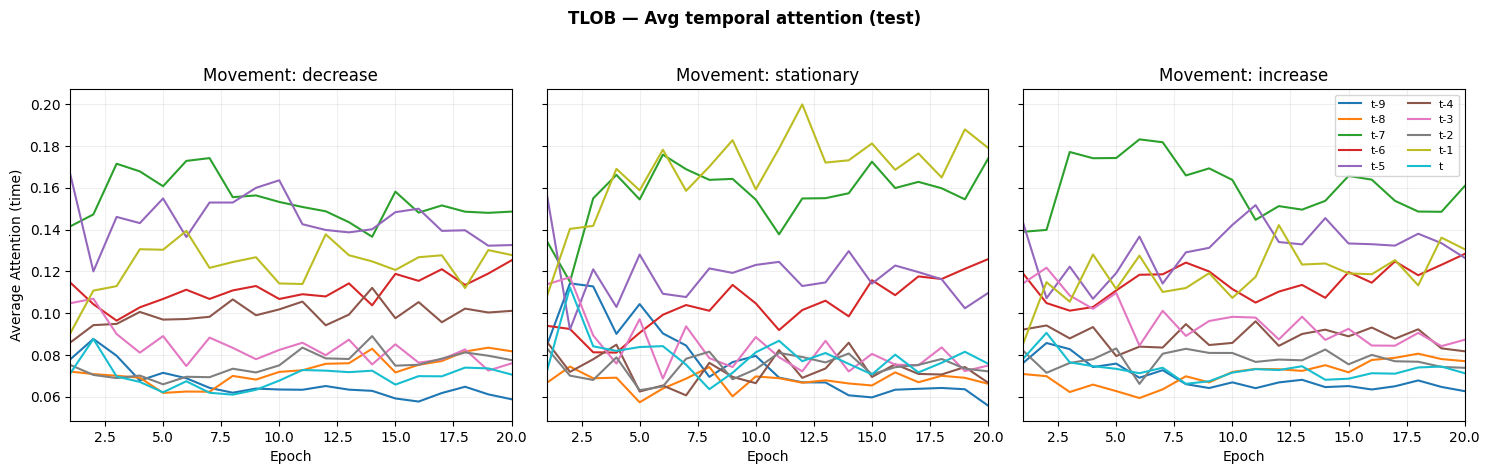

Fold 4 TEST | loss 0.4033 acc 0.8127 macroF1 0.7940

===== Fold 5: Train days 1..5 | Test day 6 =====
Epoch 001 | tr_loss 0.4934 acc 0.7932 | val_loss 0.4300 acc 0.8032 macroF1 0.7863
Epoch 002 | tr_loss 0.4054 acc 0.8170 | val_loss 0.4099 acc 0.7957 macroF1 0.7820
Epoch 003 | tr_loss 0.3894 acc 0.8177 | val_loss 0.4002 acc 0.7980 macroF1 0.7831
Epoch 004 | tr_loss 0.3754 acc 0.8198 | val_loss 0.3957 acc 0.7910 macroF1 0.7773
Epoch 005 | tr_loss 0.3675 acc 0.8217 | val_loss 0.3908 acc 0.7920 macroF1 0.7787
Epoch 006 | tr_loss 0.3588 acc 0.8224 | val_loss 0.4042 acc 0.8097 macroF1 0.7940
Epoch 007 | tr_loss 0.3479 acc 0.8251 | val_loss 0.4016 acc 0.7950 macroF1 0.7812
Epoch 008 | tr_loss 0.3404 acc 0.8274 | val_loss 0.3958 acc 0.7946 macroF1 0.7809
Epoch 009 | tr_loss 0.3295 acc 0.8312 | val_loss 0.4129 acc 0.8036 macroF1 0.7889
Epoch 010 | tr_loss 0.3200 acc 0.8333 | val_loss 0.4166 acc 0.8038 macroF1 0.7878
Epoch 011 | tr_loss 0.3095 acc 0.8358 | val_loss 0.4523 acc 0.8108 macroF1 0.7

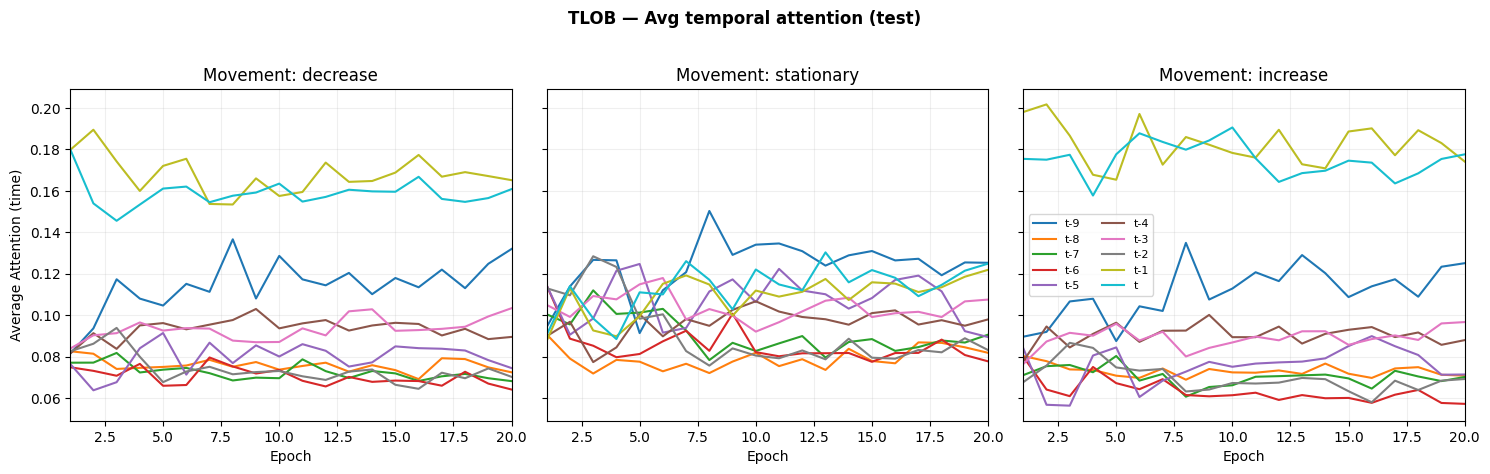

Fold 5 TEST | loss 0.3975 acc 0.8245 macroF1 0.8004

===== Fold 6: Train days 1..6 | Test day 7 =====
Epoch 001 | tr_loss 0.4849 acc 0.7913 | val_loss 0.4088 acc 0.8149 macroF1 0.7824
Epoch 002 | tr_loss 0.4006 acc 0.8165 | val_loss 0.3885 acc 0.8154 macroF1 0.7833
Epoch 003 | tr_loss 0.3834 acc 0.8180 | val_loss 0.3844 acc 0.8201 macroF1 0.7879
Epoch 004 | tr_loss 0.3731 acc 0.8188 | val_loss 0.3715 acc 0.8155 macroF1 0.7837
Epoch 005 | tr_loss 0.3657 acc 0.8190 | val_loss 0.3749 acc 0.8137 macroF1 0.7829
Epoch 006 | tr_loss 0.3562 acc 0.8214 | val_loss 0.3789 acc 0.8137 macroF1 0.7815
Epoch 007 | tr_loss 0.3493 acc 0.8227 | val_loss 0.3872 acc 0.8241 macroF1 0.7908
Epoch 008 | tr_loss 0.3416 acc 0.8250 | val_loss 0.3820 acc 0.8221 macroF1 0.7893
Epoch 009 | tr_loss 0.3352 acc 0.8255 | val_loss 0.3802 acc 0.8112 macroF1 0.7789
Epoch 010 | tr_loss 0.3285 acc 0.8270 | val_loss 0.3835 acc 0.8158 macroF1 0.7840
Epoch 011 | tr_loss 0.3216 acc 0.8295 | val_loss 0.4025 acc 0.8274 macroF1 0.7

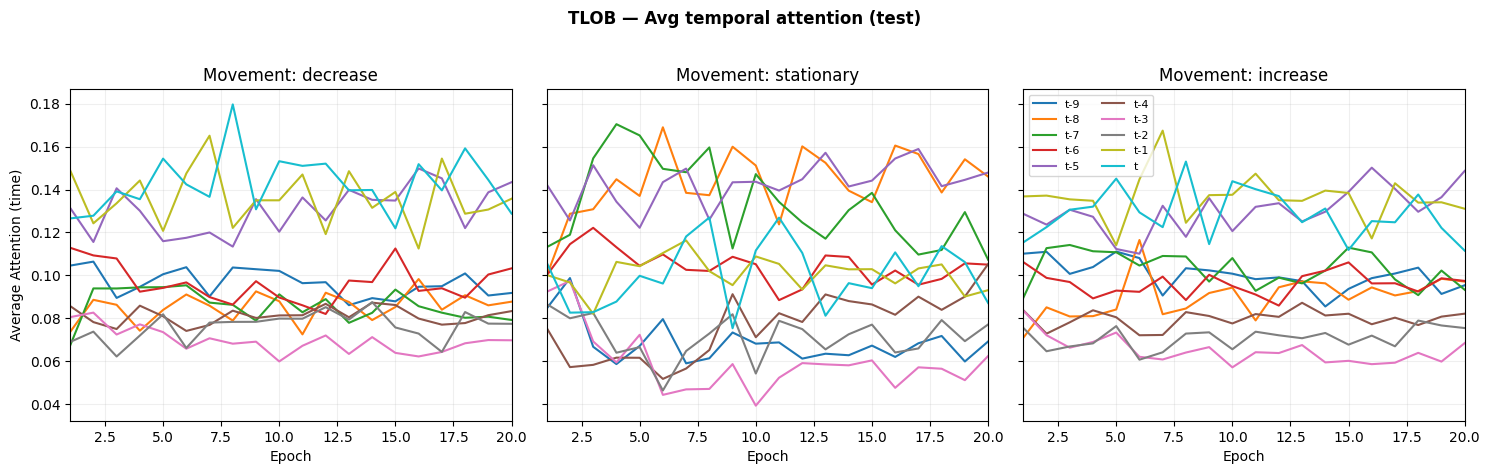

Fold 6 TEST | loss 0.4124 acc 0.8155 macroF1 0.7974

===== Fold 7: Train days 1..7 | Test day 8 =====
Epoch 001 | tr_loss 0.4784 acc 0.7954 | val_loss 0.3879 acc 0.8306 macroF1 0.7954
Epoch 002 | tr_loss 0.4035 acc 0.8138 | val_loss 0.3658 acc 0.8256 macroF1 0.7919
Epoch 003 | tr_loss 0.3870 acc 0.8147 | val_loss 0.3644 acc 0.8277 macroF1 0.7942
Epoch 004 | tr_loss 0.3766 acc 0.8173 | val_loss 0.3626 acc 0.8276 macroF1 0.7940
Epoch 005 | tr_loss 0.3676 acc 0.8185 | val_loss 0.3765 acc 0.8314 macroF1 0.7971
Epoch 006 | tr_loss 0.3601 acc 0.8205 | val_loss 0.3676 acc 0.8270 macroF1 0.7937
Epoch 007 | tr_loss 0.3525 acc 0.8217 | val_loss 0.3697 acc 0.8261 macroF1 0.7915
Epoch 008 | tr_loss 0.3442 acc 0.8235 | val_loss 0.3659 acc 0.8370 macroF1 0.8008
Epoch 009 | tr_loss 0.3366 acc 0.8257 | val_loss 0.3800 acc 0.8370 macroF1 0.8018
Epoch 010 | tr_loss 0.3289 acc 0.8288 | val_loss 0.3699 acc 0.8255 macroF1 0.7918
Epoch 011 | tr_loss 0.3203 acc 0.8307 | val_loss 0.3787 acc 0.8318 macroF1 0.7

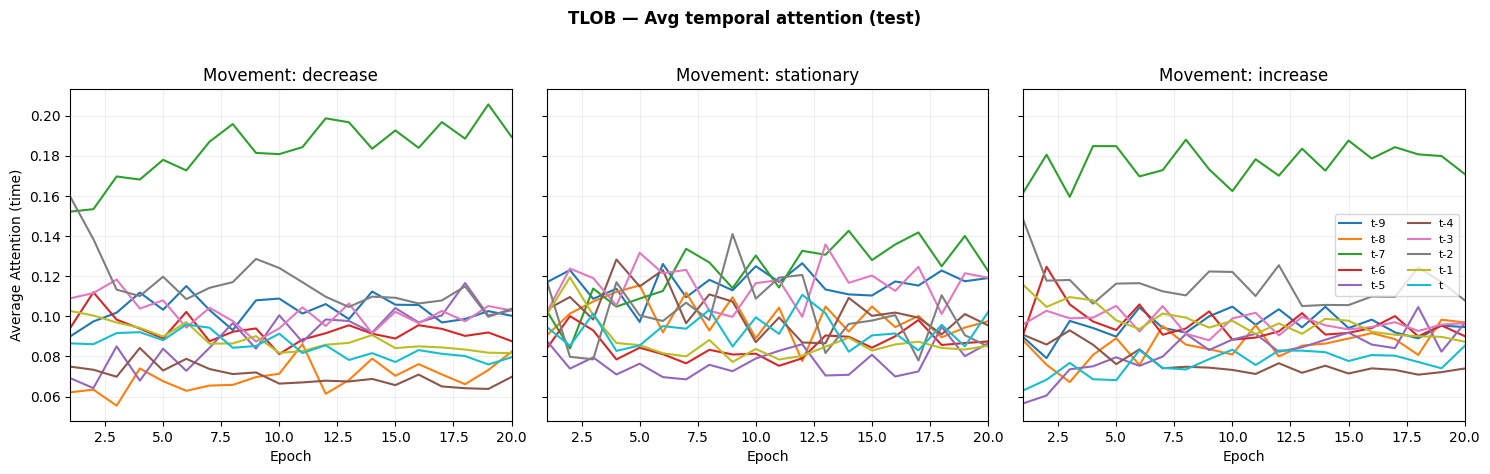

Fold 7 TEST | loss 0.2910 acc 0.8765 macroF1 0.8180

===== Fold 8: Train days 1..8 | Test day 9 =====
Epoch 001 | tr_loss 0.4591 acc 0.8043 | val_loss 0.3293 acc 0.8533 macroF1 0.7958
Epoch 002 | tr_loss 0.3870 acc 0.8195 | val_loss 0.3066 acc 0.8540 macroF1 0.7979
Epoch 003 | tr_loss 0.3715 acc 0.8209 | val_loss 0.3119 acc 0.8532 macroF1 0.7978
Epoch 004 | tr_loss 0.3622 acc 0.8221 | val_loss 0.2968 acc 0.8578 macroF1 0.8032
Epoch 005 | tr_loss 0.3539 acc 0.8245 | val_loss 0.2991 acc 0.8559 macroF1 0.8008
Epoch 006 | tr_loss 0.3467 acc 0.8253 | val_loss 0.2939 acc 0.8590 macroF1 0.8047
Epoch 007 | tr_loss 0.3395 acc 0.8271 | val_loss 0.2980 acc 0.8633 macroF1 0.8072
Epoch 008 | tr_loss 0.3325 acc 0.8280 | val_loss 0.3025 acc 0.8573 macroF1 0.8008
Epoch 009 | tr_loss 0.3248 acc 0.8299 | val_loss 0.3009 acc 0.8606 macroF1 0.8061
Epoch 010 | tr_loss 0.3170 acc 0.8320 | val_loss 0.3061 acc 0.8548 macroF1 0.8002
Epoch 011 | tr_loss 0.3099 acc 0.8339 | val_loss 0.3063 acc 0.8653 macroF1 0.8

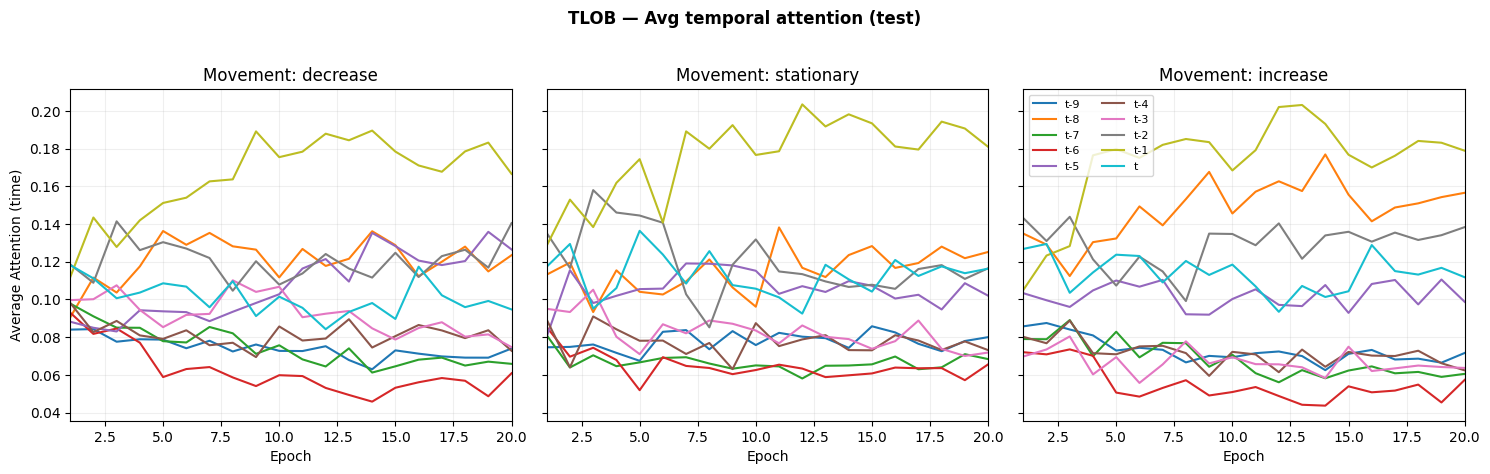

Fold 8 TEST | loss 0.3257 acc 0.8597 macroF1 0.8102

===== Fold 9: Train days 1..9 | Test day 10 =====
Epoch 001 | tr_loss 0.4449 acc 0.8096 | val_loss 0.3232 acc 0.8527 macroF1 0.7837
Epoch 002 | tr_loss 0.3822 acc 0.8230 | val_loss 0.2927 acc 0.8806 macroF1 0.8127
Epoch 003 | tr_loss 0.3668 acc 0.8248 | val_loss 0.2843 acc 0.8666 macroF1 0.7994
Epoch 004 | tr_loss 0.3577 acc 0.8261 | val_loss 0.2876 acc 0.8605 macroF1 0.7946
Epoch 005 | tr_loss 0.3495 acc 0.8267 | val_loss 0.2820 acc 0.8638 macroF1 0.8000
Epoch 006 | tr_loss 0.3437 acc 0.8282 | val_loss 0.2924 acc 0.8594 macroF1 0.7935
Epoch 007 | tr_loss 0.3381 acc 0.8286 | val_loss 0.2745 acc 0.8688 macroF1 0.8047
Epoch 008 | tr_loss 0.3305 acc 0.8303 | val_loss 0.2754 acc 0.8738 macroF1 0.8096
Epoch 009 | tr_loss 0.3254 acc 0.8314 | val_loss 0.2769 acc 0.8729 macroF1 0.8091
Epoch 010 | tr_loss 0.3184 acc 0.8330 | val_loss 0.2859 acc 0.8783 macroF1 0.8121
Epoch 011 | tr_loss 0.3114 acc 0.8342 | val_loss 0.2894 acc 0.8752 macroF1 0.

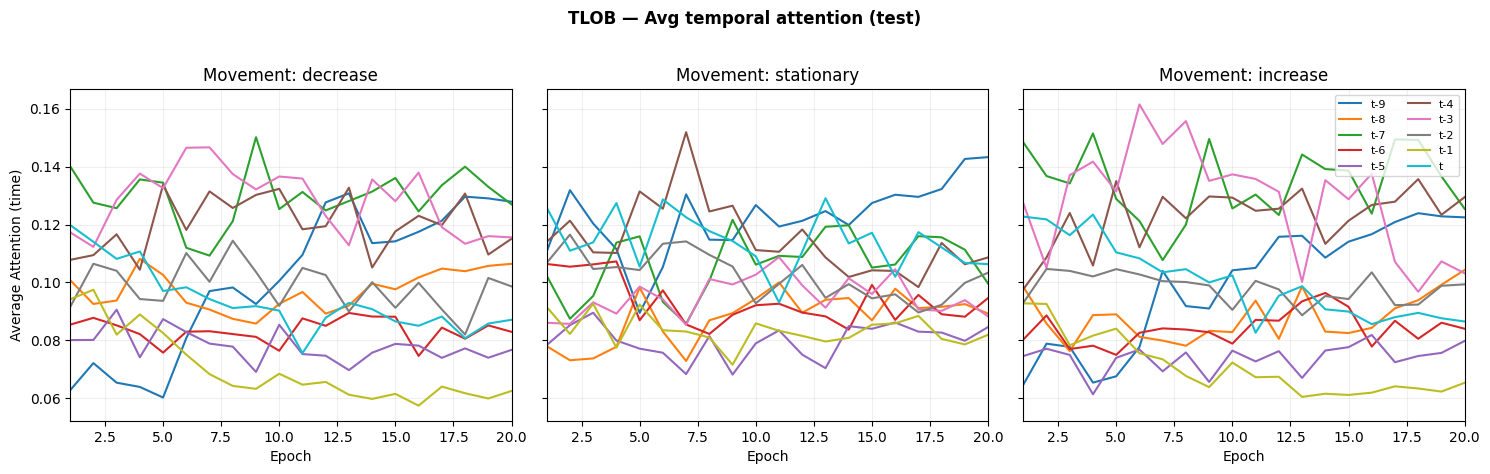

Fold 9 TEST | loss 0.3576 acc 0.8508 macroF1 0.8122

===== WALK-FORWARD SUMMARY: TLOB (dual-attn + BiN + sinusoidal PE) =====
Test Acc    mean=0.8341 std=0.0220
Test MacroF1 mean=0.8016 std=0.0091


In [ ]:
tlob_results = run_walk_forward_cv(
    model_builder=lambda: TLOBClassifier(
        num_classes=3,
        input_dim=144,
        time_steps=10,
        d_model=144,
        n_layers=2,
        n_heads_time=4,
        d_feat_attn=64,
        n_heads_feat=4,
        dropout=0.1,
        use_bin=True,
        use_pos_enc=True,
        cls_pool="last",
    ),

    model_name="TLOB",
    epochs=20,
    lr=1e-3,
    val_ratio=0.1,
    track_attention=True,
    attention_on='test',
    attention_every=1,
    attention_collector=collect_avg_time_attention_per_class,
    plot_attention=True,
    plot_attention_title="TLOB — Avg temporal attention (test)"
)

In [ ]:
df_mlp, sum_mlp = summarize_cv(mlp_results, "MLP")
df_cnn, sum_cnn = summarize_cv(cnn_results, "CNN")
df_lstm, sum_lstm = summarize_cv(lstm_results, "LSTM")
df_tcn, sum_tcn = summarize_cv(tcn_results, "TCN")
df_tabl, sum_tabl = summarize_cv(tabl_results, "TABL")
df_tlob, sum_tlob = summarize_cv(tlob_results, "TLOB")


In [ ]:
summary_df = pd.DataFrame([sum_mlp, sum_cnn, sum_lstm, sum_tcn, sum_tlob, sum_tabl]).sort_values("f1_mean", ascending=False)
summary_df


,model,acc_mean,acc_std,f1_mean,f1_std
4,TLOB,0.834058,0.022042,0.801550,0.009055
5,TABL,0.810386,0.035173,0.766639,0.028754
3,TCN,0.795736,0.055603,0.748400,0.048497
1,CNN,0.782846,0.051798,0.734288,0.043718
2,LSTM,0.754837,0.058733,0.702612,0.051119
0,MLP,0.756892,0.070609,0.697623,0.059215


In [ ]:
results_dict = {
    "MLP": mlp_results,
    "CNN": cnn_results,
    "TCN": tcn_results,
    "LSTM": lstm_results,
    "TABL": tabl_results,
    "TLOB": tlob_results,
}

NameError: name 'mlp_results' is not defined

In [ ]:
def set_modern_mpl_style():
    """ Configure matplotlib with moder, publication-ready styling. """
    plt.rcParams.update({
        # Figure resolution
        "figure.dpi": 120,
        "savefig.dpi": 300,

        # Grid styling
        "axes.grid": True,
        "grid.alpha": 0.25,
        "grid.linestyle": "-",

        # Remove top/right spines for cleaner look
        "axes.spines.top": False,
        "axes.spines.right": False,

        # Title and label formatting
        "axes.titleweight": "bold",
        "axes.labelsize": 11,
        "axes.titlesize": 13,

        # Legend styling
        "legend.frameon": True,
        "legend.framealpha": 0.9,
        "legend.fancybox": True,

        # Line appearance
        "lines.linewidth": 2.2,
        "lines.markersize": 6,

        # Tick label sizes
        "xtick.labelsize": 10,
        "ytick.labelsize": 10,
    })

# Apply style on import
set_modern_mpl_style()

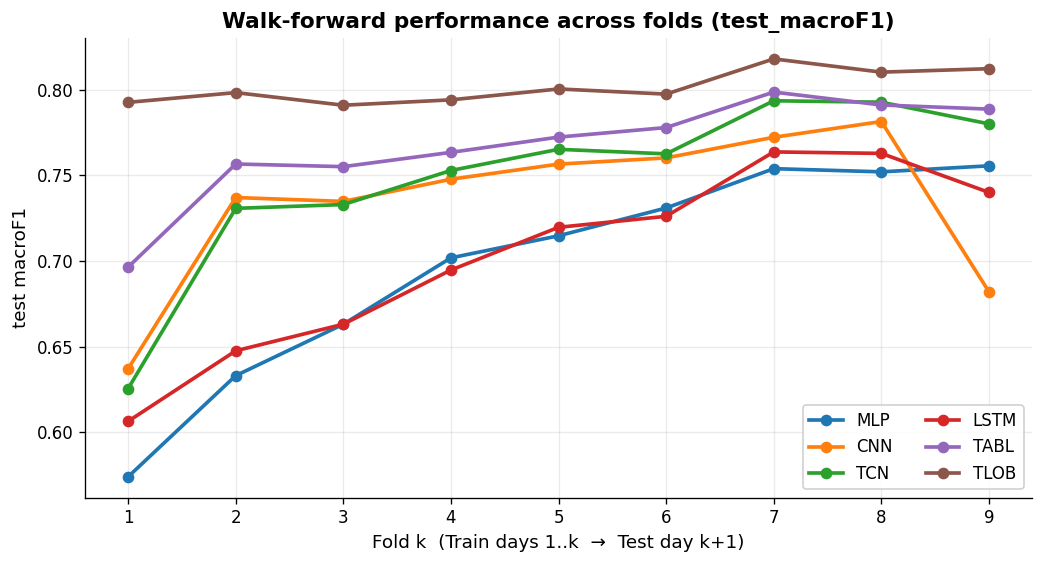

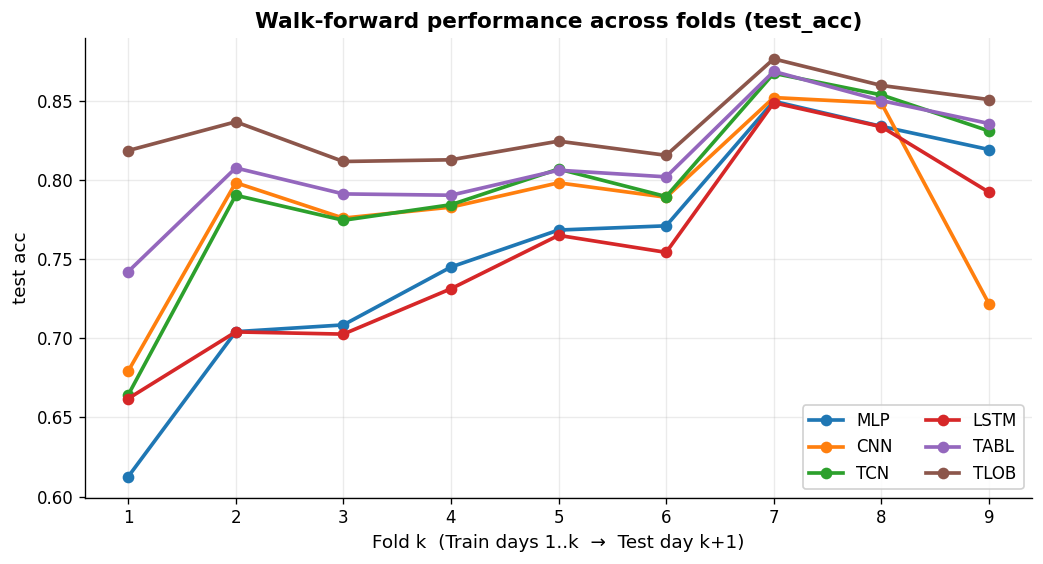

In [ ]:
def plot_walk_forward(
    results_dict: Dict[str, List[Dict[str, Any]]],
    metric: str = "test_macroF1",
    title: Optional[str] = None,
    figsize: Tuple[float, float] = (8.8, 4.8),
) -> None:
    """
    Plot walk-forward cross-validation results across folds.

    Visualizes how each model's performance evolves as more training
    data becomes available (expanding window approach).

    Args:
        results_dict: Dictionary mapping model names to their fold results.
            Each result should contain 'fold' and the specified metric.
        metric: Metric key to plot (e.g., 'test_f1', 'test_acc').
        title: Custom plot title. Auto-generated if None.
        figsize: Figure size as (width, height).
    """

    plt.figure(figsize=figsize)
    
    for model_name, fold_results in results_dict.items():
        folds = [r["fold"] for r in fold_results]
        vals  = [r[metric] for r in fold_results]
        plt.plot(folds, vals, marker="o", label=model_name) 

    # Configure axes
    plt.xticks(range(1, max(folds) + 1))
    plt.xlabel("Fold k  (Train days 1..k  →  Test day k+1)")
    plt.ylabel(metric.replace("_", " "))
    
    if title is None:
        metric_display = metric.replace("_", " ").title()
        title = f"Walk-Forward Performance: ({metric_display})"

    plt.title(title)
    
    plt.legend(ncol=2, loc="best")
    plt.tight_layout()
    plt.show()

# Plot results
plot_walk_forward(results_dict, metric="test_macroF1")
plot_walk_forward(results_dict, metric="test_acc")


In [ ]:
def bar_mean_std(
    results_dict: Dict[str, List[Dict[str, Any]]], 
    metric : str ="test_macroF1",
    title: str = "test_f1",
    figsize: Tuple[int, int] = (8.8, 4.8),
    capsize: int = 6,
) -> None:
    """
    Plot bar chart comparing model performance with error bars.
    
    Shows mean and standard deviation of the specified metric
    across all folds for each model.
    
    Args:
        results_dict: Dictionary mapping model names to their fold results.
        metric: Metric key to compare (e.g., 'test_f1', 'test_acc').
        title: Custom plot title. Auto-generated if None.
        figsize: Figure size as (width, height).
        capsize: Size of error bar caps.
    """
    model_names = list(results_dict.keys())
    num_folds = len(results_dict[model_names[0]])

    # Compute statistics for each model
    means = []
    stds  = []

    for name in model_names:
        values = np.array([r[metric] for r in results_dict[name]])
        means.append(values.mean())
        stds.append(values.std(ddof=0))
    
    # Create bar plot
    x_positions = np.arange(len(model_names))
    plt.figure(figsize=figsize)
    plt.bar(x_positions, means, yerr=stds, capsize=capsize, color="steelblue", alpha=0.8)
    
    # Configure axes
    plt.xticks(x_positions, model_names, rotation=0)

    metric_display = metric.replace("_", " ")
    plt.ylabel(f"{metric_display} (mean ± std over {num_folds} folds)")
    
    # Set title
    if title is None:
        title = f"Model comparison: {metric_display}"

    plt.title(title)
    
    plt.tight_layout()
    plt.show()

# Compare models
bar_mean_std(results_dict, metric="test_macroF1")
bar_mean_std(results_dict, metric="test_acc")



NameError: name 'results_dict' is not defined

In [ ]:
def plot_metric_distribution(
    results_dict: Dict[str, List[Dict[str, Any]]],
    metric: str = "test_f1",
    title: Optional[str] = None,
    figsize: tuple = (8.8, 4.8),
    show_means: bool = True,
) -> None:
    """
    Plot boxplot showing metric distribution across folds for each model.
    Visualizes fold-to-fold variability to assess model stability.
    Args:
        results_dict: Dictionary mapping model names to their fold results.
        metric: Metric key to visualize (e.g., 'test_f1', 'test_acc').
        title: Custom plot title. Auto-generated if None.
        figsize: Figure size as (width, height).
        show_means: Whether to show mean markers on boxplots.
    Example:
        >>> results = {"MLP": mlp_results, "TABL": tabl_results}
        >>> plot_metric_distribution(results, metric="test_f1")
    """
    model_names = list(results_dict.keys())

    # Extract metric values for each model
    data = [
        [r[metric] for r in results_dict[name]]
        for name in model_names
    ]

    # Create boxplot
    plt.figure(figsize=figsize)
    plt.boxplot(data, labels=model_names, showmeans=show_means)

    # Configure axes
    metric_display = metric.replace("_", " ").title()
    plt.ylabel(metric_display)

    # Set title
    if title is None:
        title = f"Fold-to-Fold Variability: {metric_display}"

    plt.title(title)

    plt.tight_layout()
    plt.show()

# Plot metric distributions
plot_metric_distribution(results_dict, metric="test_f1")

NameError: name 'results_dict' is not defined

In [ ]:
def plot_performance_heatmap(
    results_dict: Dict[str, List[Dict[str, Any]]],
    metric: str = "test_f1",
    title: Optional[str] = None,
    figsize: tuple = (9.2, 4.4),
    cmap: str = "viridis",
    annotate: bool = True,
) -> None:
    """
    Plot heatmap of model performance across folds.
    Visualizes the metric value for each model-fold combination,
    useful for identifying patterns in model behavior across folds.
    Args:
        results_dict: Dictionary mapping model names to their fold results.
        metric: Metric key to visualize (e.g., 'test_f1', 'test_acc').
        title: Custom plot title. Auto-generated if None.
        figsize: Figure size as (width, height).
        cmap: Colormap for the heatmap.
        annotate: Whether to show values in cells.
    Example:
        >>> results = {"MLP": mlp_results, "TABL": tabl_results}
        >>> plot_performance_heatmap(results, metric="test_f1")
    """
    model_names = list(results_dict.keys())
    num_folds = len(results_dict[model_names[0]])

    # Build matrix: (num_models, num_folds)
    matrix = np.array([
        [r[metric] for r in results_dict[name]]
        for name in model_names
    ])

    # Create heatmap
    plt.figure(figsize=figsize)
    im = plt.imshow(matrix, aspect="auto", cmap=cmap)

    metric_display = metric.replace("_", " ").title()
    plt.colorbar(im, label=metric_display)

    # Add cell annotations
    if annotate:
        for i in range(len(model_names)):
            for j in range(num_folds):
                value = matrix[i, j]
                text_color = "white" if value < matrix.mean() else "black"
                plt.text(j, i, f"{value:.2f}", ha="center", va="center", color=text_color, fontsize=8)
    
    # Configure axes
    plt.yticks(range(len(model_names)), model_names)
    plt.xticks(range(num_folds), range(1, num_folds + 1))
    plt.xlabel("Fold")
    plt.ylabel("Model")
    
    # Set title
    if title is None:
        title = f"Performance Heatmap: {metric_display}"
    
    plt.title(title)
    
    plt.tight_layout()
    plt.show()

# Plot heatmap
plot_performance_heatmap(results_dict, metric="test_f1")

NameError: name 'results_dict' is not defined

In [ ]:
def plot_confusion_matrix(
    results: List[Dict[str, Any]],
    title: str = "Confusion Matrix",
    normalize: Optional[Literal["true"]] = None,
    annotate: bool = True,
    figsize: tuple = (6.2, 5.4),
    cmap: str = "YlGnBu",
) -> None:
    """
    Plot confusion matrix from cross-validation results.
    Aggregates predictions from all folds and displays the confusion matrix
    as a heatmap with optional normalization and cell annotations.
    Args:
        results: List of fold result dictionaries containing 'y_true' and 'y_pred'.
        title: Plot title.
        normalize: Normalization mode:
            - None: Show raw counts.
            - "true": Normalize by true class (rows sum to 1).
        annotate: Whether to show values in cells.
        figsize: Figure size as (width, height).
        cmap: Colormap for the heatmap.
    Example:
        >>> plot_confusion_matrix(mlp_results, title="MLP Confusion Matrix")
        >>> plot_confusion_matrix(mlp_results, normalize="true")  # Show percentages
    """
    # Aggregate predictions from all folds
    y_true = np.concatenate([r["y_true"] for r in results])
    y_pred = np.concatenate([r["y_pred"] for r in results])

    # Compute confusion matrix
    cm = confusion_matrix(y_true, y_pred, labels=[0, 1, 2])

    # Normalize if requested
    if normalize is None:
        cm_display = cm.astype(float)
        colorbar_label = "Count"
        value_format = "d"

    elif normalize == "true":
        row_sums = cm.sum(axis=1, keepdims=True)
        cm_display = cm.astype(float) / np.maximum(row_sums, 1)
        colorbar_label = "Ratio (per true class)"
        value_format = ".2f"

    else:
        raise ValueError(f'normalize must be "true" or None, got {normalize}')

    # Create figure
    fig, ax = plt.subplots(figsize=figsize)

    # Plot heatmap
    vmin, vmax = (0.0, 1.0) if normalize == "true" else (None, None)
    im = ax.imshow(cm_display, cmap=cmap, vmin=vmin, vmax=vmax, aspect="equal")

    # Add colorbar
    cbar = fig.colorbar(im, ax=ax)
    cbar.set_label(colorbar_label)

    # Configure axes
    num_classes = len(CLASS_LABELS)
    ax.set_xticks(range(num_classes))
    ax.set_yticks(range(num_classes))
    ax.set_xticklabels(CLASS_LABELS)
    ax.set_yticklabels(CLASS_LABELS)
    ax.set_xlabel("Predicted")
    ax.set_ylabel("True")
    ax.set_title(title)

    # Add grid lines between cells
    ax.set_xticks(np.arange(-0.5, num_classes, 1), minor=True)
    ax.set_yticks(np.arange(-0.5, num_classes, 1), minor=True)
    ax.grid(which="minor", linestyle="-", linewidth=1, alpha=0.25)
    ax.tick_params(which="minor", bottom=False, left=False)

    # Add cell annotations
    if annotate:
        threshold = (cm_display.max() + cm_display.min()) / 2.0
        
        for i in range(num_classes):
            for j in range(num_classes):
                value = cm_display[i, j]
                
                # Format value based on normalization
                if normalize is None:
                    text = f"{int(value):d}"
                else:
                    text = f"{value:.2f}"
                
                # Choose text color for readability
                text_color = "white" if value > threshold else "black"
                ax.text(j, i, text, ha="center", va="center", color=text_color, fontsize=11)

    fig.tight_layout()
    plt.show()

In [ ]:
# Plot confusion matrices for all models
for model_name, results in results_dict.items():
    print(f"\nConfusion Matrix: {model_name}")
    
    # Raw counts
    plot_confusion_matrix(
        results,
        title=f"{model_name} — Confusion Matrix",
        normalize=None,
        annotate=True,
    )
    
    # Normalized by true class
    plot_confusion_matrix(
        results,
        title=f"{model_name} — Confusion Matrix (Normalized)",
        normalize="true",
        annotate=True,
    )

NameError: name 'results_dict' is not defined